## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=79, experiments_root="/home/data/saeid/experiments")
df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


,end_to_end_s
count,8800.000000
mean,62.974603
std,112.470767
min,0.961160
50%,24.417330
90%,145.435281
99%,628.648521
max,1112.050920


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,ttft_s,tpot_avg_s,streaming,endpoint_id
0,0,07c0454be3e046c1bacff0ac49212fe9,False,4.62884,4.62884,stop,39,121,None,0.56016,0.03391,True,vllm-minimax-m2-0
1,1,ec3f184bd37d42c5a668cf8110873b68,False,2.64427,2.64427,stop,40,61,None,0.56234,0.03470,True,vllm-minimax-m2-0
2,2,7ff68aea4af146859cfa292224827845,False,6.74867,6.74867,stop,69,177,None,0.57575,0.03507,True,vllm-minimax-m2-1
3,3,c8a53f58b43f4ec3b6c651720bc4bdc4,False,16.92239,16.92239,stop,49,494,None,0.63013,0.03305,True,vllm-minimax-m2-0
4,4,1a7d547f60e64825900eb2fb9f22ddc3,False,1.27484,1.27484,length,12701,1,None,1.09803,NaN,NaN,vllm-minimax-m2-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8795,8795,c179fe8885764757a9627fc663519dcc,False,857.33296,857.33296,stop,64489,2544,None,140.27928,0.28197,True,vllm-minimax-m2-0
8796,8796,5c61f9e3709543bf8ab964ab7c0d278d,False,64.43291,64.43291,tool_calls,13573,185,None,16.22811,0.26198,True,vllm-minimax-m2-0
8797,8797,9e3dbb444e294f93bb01b0a15bb189fa,False,218.75810,218.75810,tool_calls,23233,258,None,93.44149,0.48761,True,vllm-minimax-m2-1
8798,8798,43766756b2d74098bb79b85818e6bdf2,False,76.50422,76.50422,tool_calls,124767,112,None,45.88968,0.27581,True,vllm-minimax-m2-0


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[79]


[79]

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 79:
  client_to_router_s          :      nan s
  router_queue_s              :      nan s
  router_to_sidecar_s         :      nan s
  sidecar_queue_s             :      nan s
  vllm_compute_s              :      nan s
  sidecar_post_s              :      nan s
  sidecar_to_router_s         :      nan s
  router_post_result_s        :      nan s
  SUM (components)            :    0.000 s

  Router post-result breakdown:
    router_result_handler_s   :      nan s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000000 s

  end_to_end_s                :   62.981 s



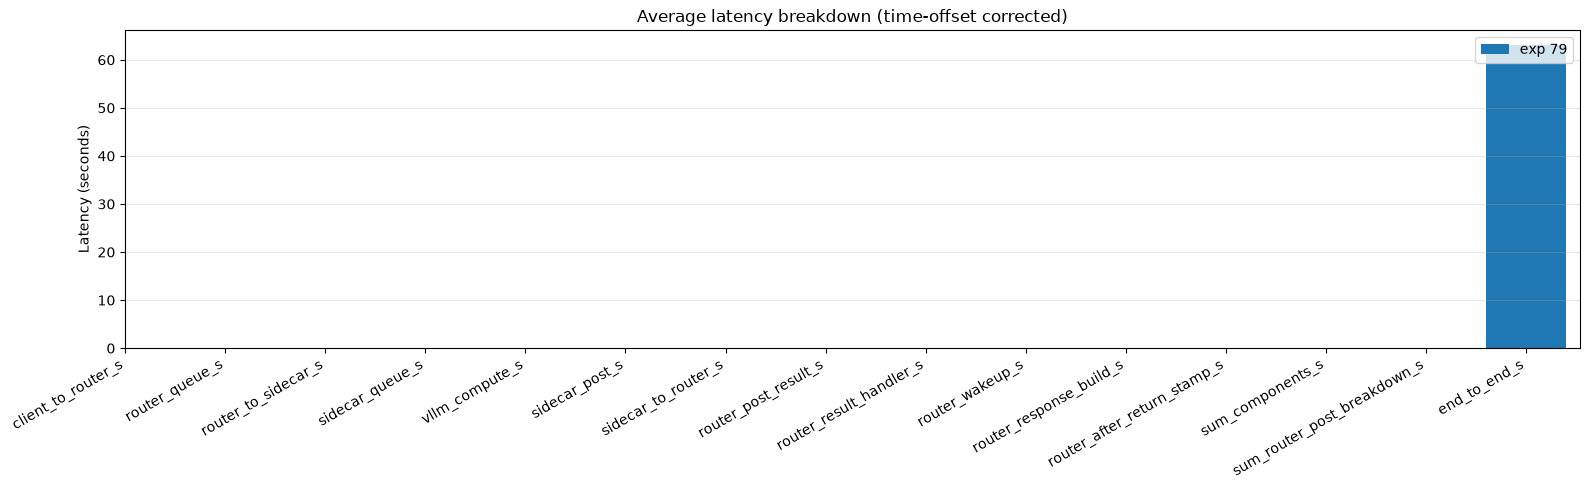

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
        experiments_root="/home/data/saeid/experiments"
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    df = df.iloc[20:]
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[79]


,exp79_end_to_end_s,exp79_ttft_s
count,8785.000000,8785.000000
mean,63.092303,6.756867
std,112.544670,32.861818
min,0.961160,0.317220
50%,24.486160,1.745050
90%,145.975278,4.318138
99%,628.793881,131.039772
max,1112.050920,777.268260


In [7]:
# from experiment_analysis import load_experiment_latencies
# import pandas as pd
# # ---- choose experiments (exclude first 20 entries) ----
# # choose which series you want
# # series_ids = [35]
# # experiments = experiments_from_series(series_ids)
# experiments = [74]
# print(experiments)
# # ----------------------------------------------
# # Latency columns of interest
# cols = [
#     "end_to_end_s",
#     # "server_roundtrip_s",
#     # "router_queue_s",
#     # "vllm_compute_s",
# ]
# percentiles = [0.5, 0.9, 0.99]
# summaries = []
# for exp_id in experiments:
#     df = load_experiment_latencies(exp_id=exp_id)
#     df = df.iloc[20:]
#     summary = (
#         df.describe(percentiles=percentiles)[cols]
#           .add_prefix(f"exp{exp_id}_")
#     )
#     summaries.append(summary)
# # Combine all experiments side-by-side
# comparison = pd.concat(summaries, axis=1)
# comparison


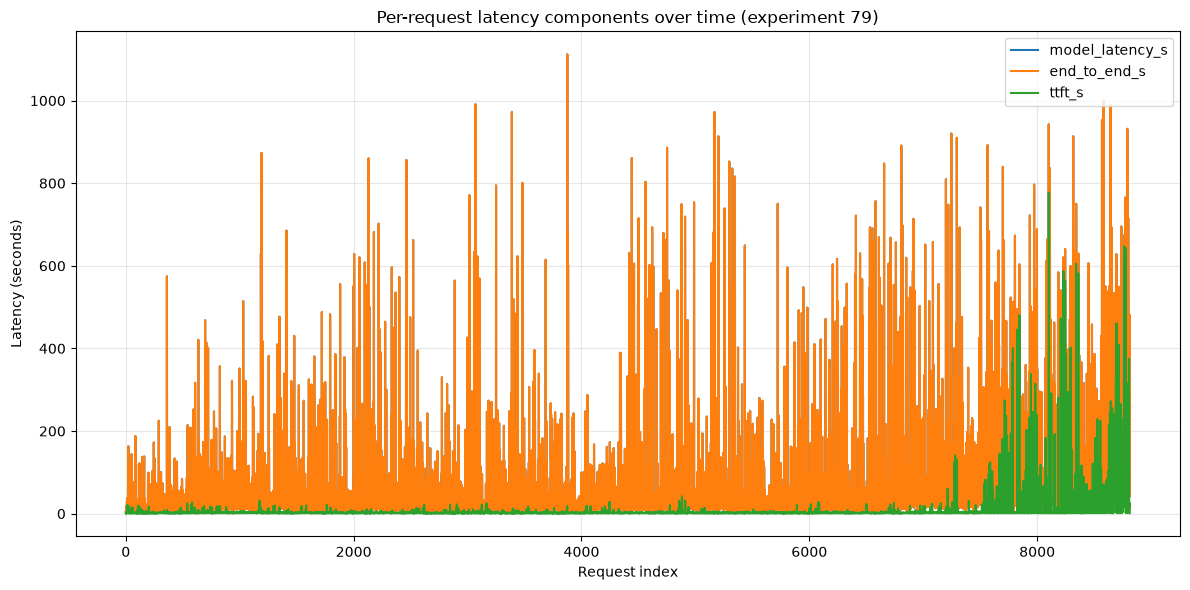

In [7]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 79
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(
    exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments").sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[79]


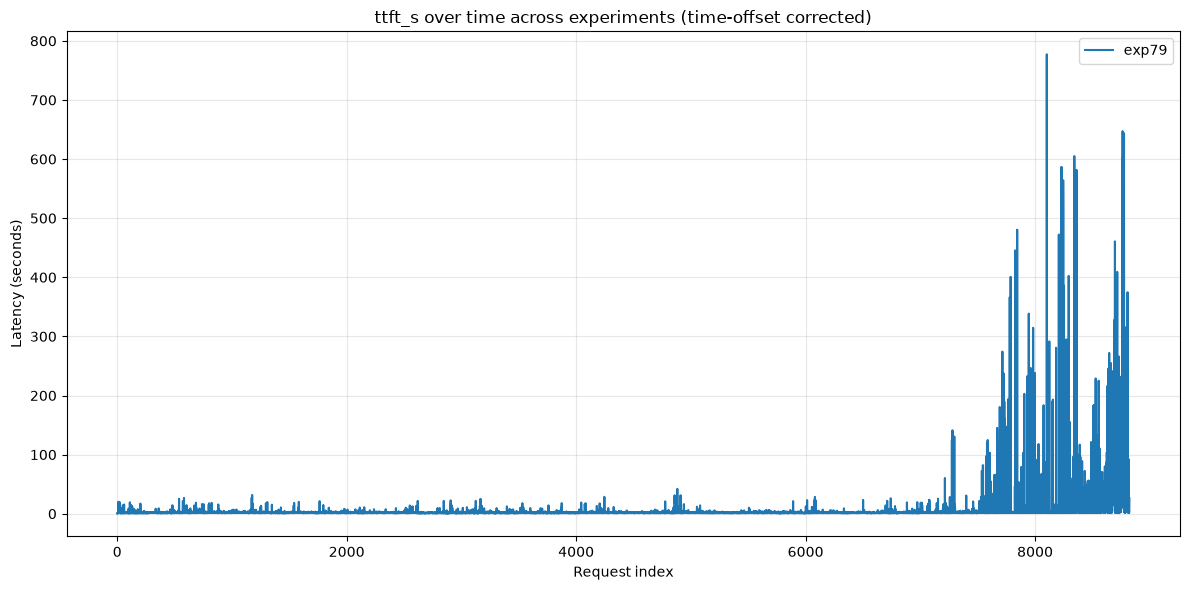

In [8]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[79]
Saved figure to /home/saeid/llm-lb/analysis-notebooks/figs/ttft_s_exp79_corrected.png


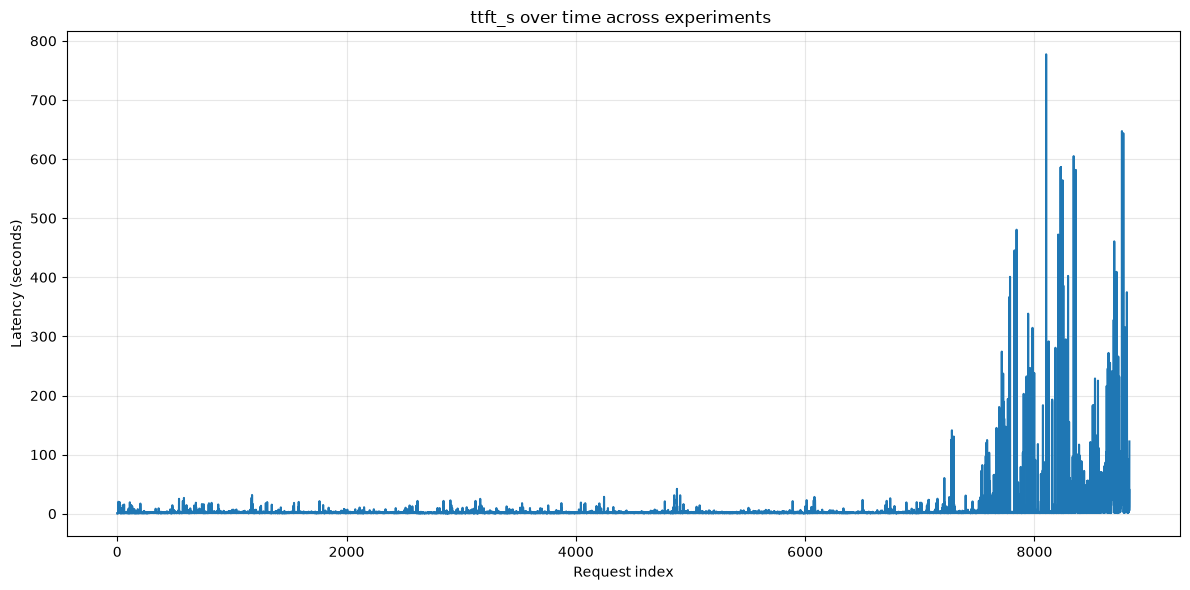

In [9]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]
print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
)
# plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# ---- save figure ----
save_dir = "/home/saeid/llm-lb/analysis-notebooks/figs"
os.makedirs(save_dir, exist_ok=True)
exp_tag = "_".join(str(e) for e in experiments)
suffix = "corrected" if APPLY_TIME_OFFSETS else "raw"
save_path = os.path.join(save_dir, f"{metric}_exp{exp_tag}_{suffix}.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {save_path}")
# ---------------------

plt.show()

## Throughput Metrics

In [10]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "preemptions_per_sec",
    # --- prefix cache rates (sum across instances) ---
    # "prefix_cache_hits_per_sec",
    # "prefix_cache_queries_per_sec",
    # "ext_prefix_cache_hits_per_sec",
    # "ext_prefix_cache_queries_per_sec",
    # "prompt_tokens_cached_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
    # "kv_cache_usage_perc",           # GPU KV cache usage (%)
    # "prefix_cache_hit_rate",         # derived: hits / queries
    # "ext_prefix_cache_hit_rate",     # derived: ext hits / ext queries
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[79]
[WARN] exp79: columns not found in prom, skipping: {'tpot_seconds_avg'}


,exp79_gen_tokens_per_sec,exp79_ttft_seconds_avg,exp79_tpot_seconds_avg
count,2563.000000,1458.000000,NaN
mean,164.437766,4.231543,NaN
std,155.932563,14.084274,NaN
min,0.000000,0.393794,NaN
50%,136.304828,1.192890,NaN
90%,384.650334,5.567720,NaN
99%,508.829116,63.599902,NaN
max,593.246897,299.957333,NaN
SLO_COMPLIANCE_%,NaN,3.086420,NaN


[79]


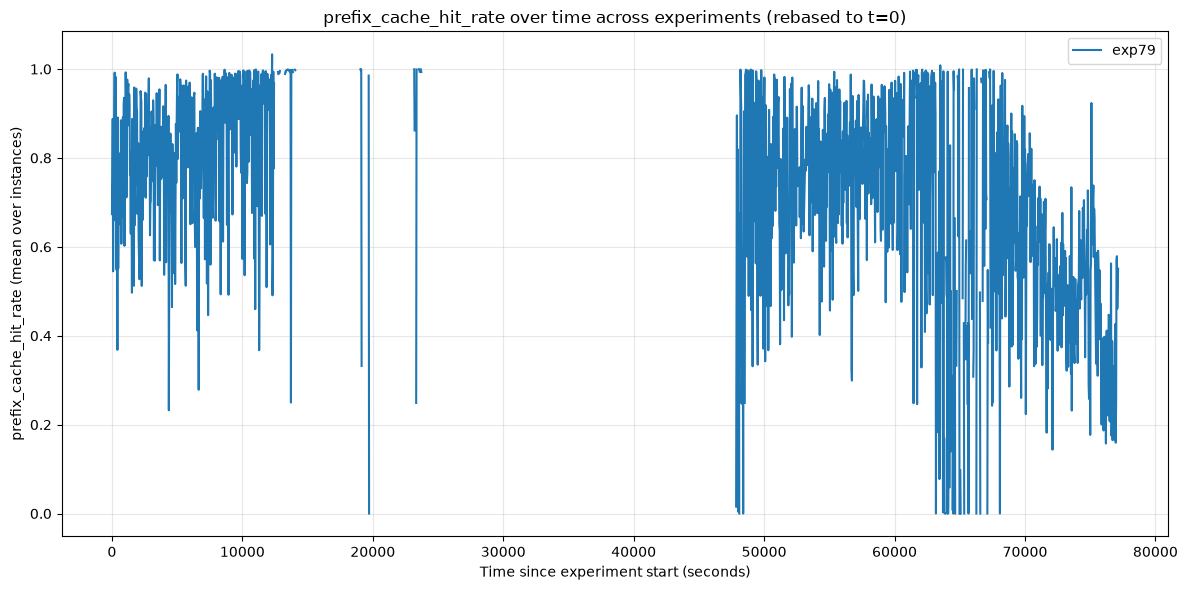

In [11]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
# agg_mode = "sum"   # cluster-level
agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[79]


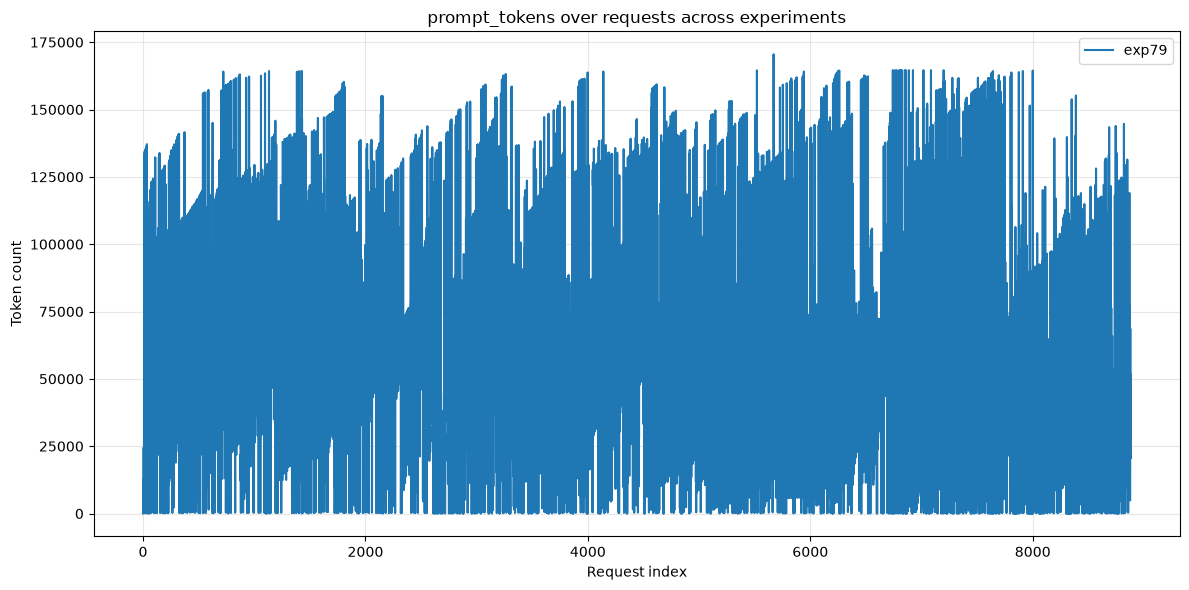

In [12]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
# metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            experiments_root="/home/data/saeid/experiments")
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [13]:
from experiment_analysis import load_experiment_latencies

experiments = [79]

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

exp79: 0 total tokens


[79]


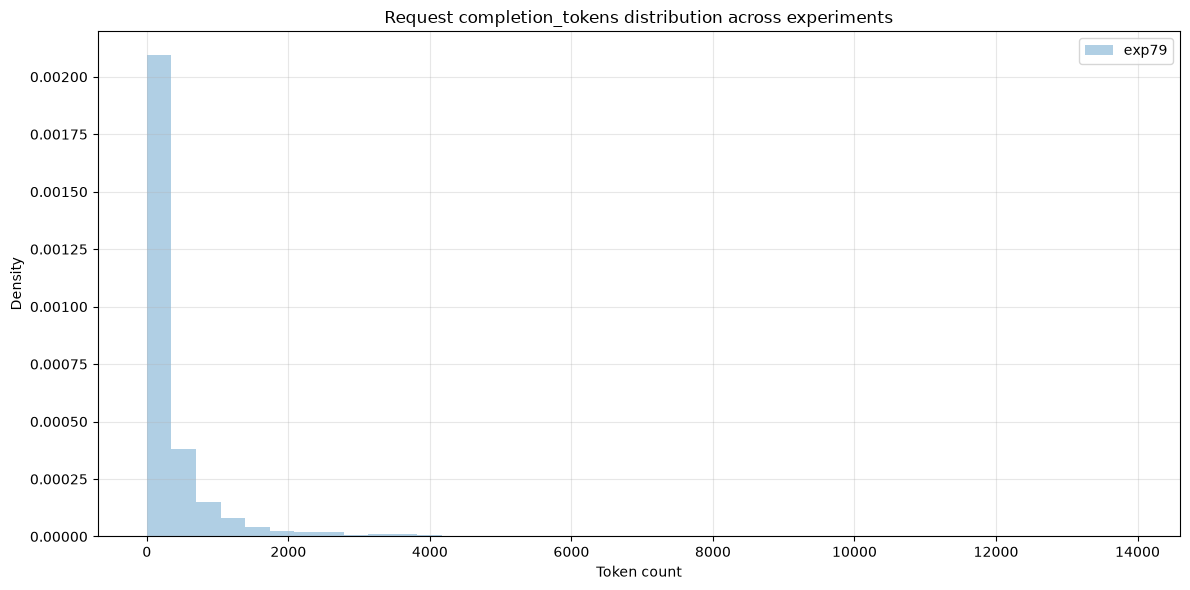

In [15]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
metric = "completion_tokens"  # output length distribution
# metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [16]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/home/data/saeid/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[79]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,79,8954,8954,0,100.0,0.0


In [17]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
    # "sidecar_workers_total",
    # "sidecar_workers_busy",
    # "sidecar_python_threads",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[79]
[WARN] exp79: no vLLM (:8200) samples found for sidecar_*


,exp79_router_queue_length,exp79_router_admission_rps,exp79_router_outgoing_rps
count,2572.000000,2572.000000,2572.000000
mean,0.319207,0.120844,0.051185
std,1.769807,0.156445,0.079040
min,0.000000,0.000000,0.000000
50%,0.000000,0.034483,0.000000
90%,0.000000,0.374428,0.172414
99%,11.000000,0.551724,0.310694
max,17.000000,0.931034,0.482759


[79]


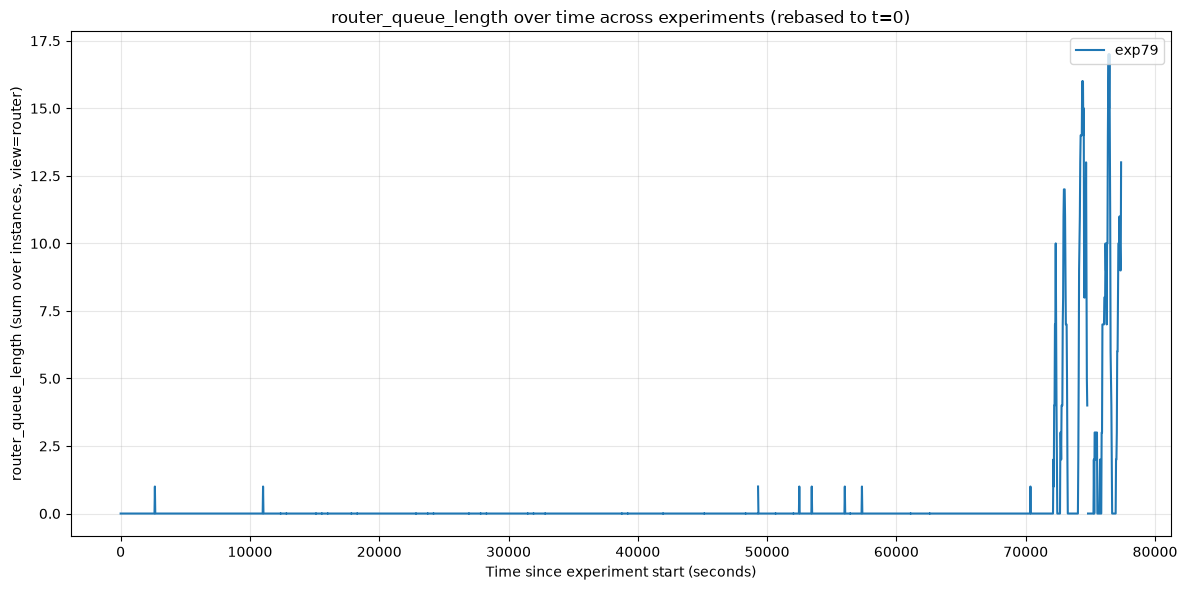

In [18]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# metric = "sidecar_workers_total"
# metric = "sidecar_workers_busy"
# metric = "sidecar_python_threads"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[79]


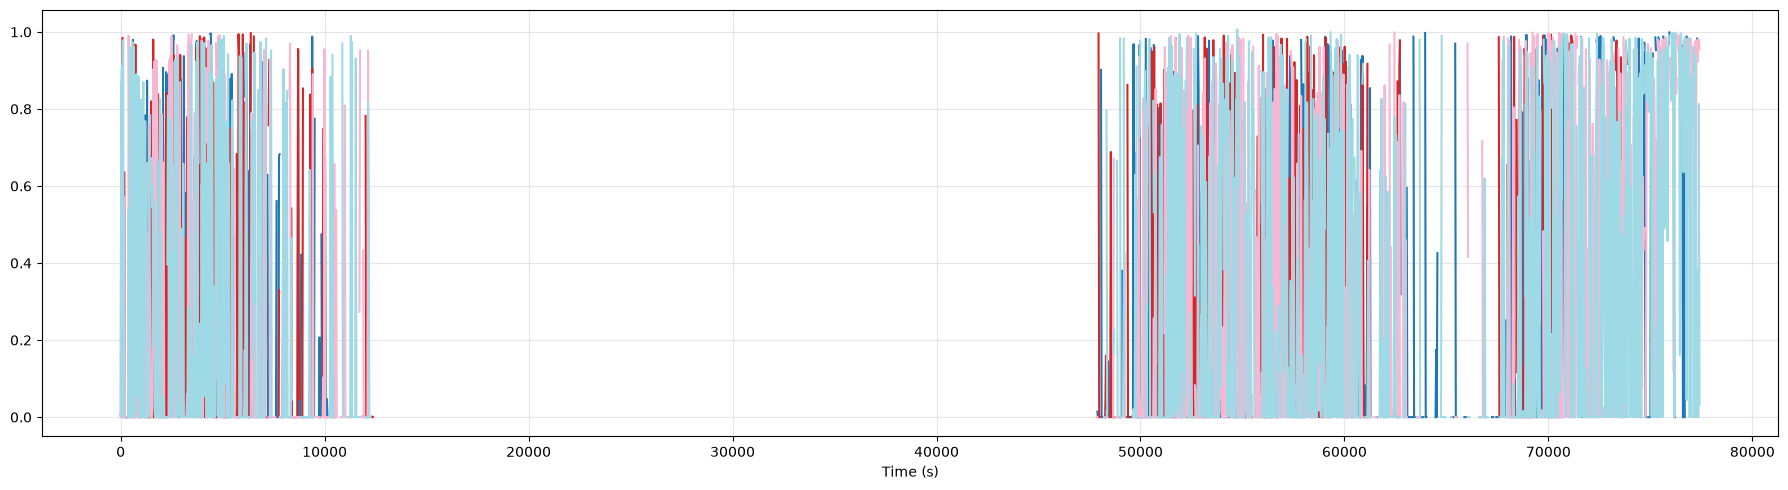

In [19]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = plt.colormaps["tab20"].resampled(len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()


In [20]:
# ============================================================
# Reproduce the dashboard's "Backend Model TPS" ranking
# (verified to match the web page exactly)
#
# Algorithm = the page's updateTPSRanking:
#   seconds   = ts[-1] - ts[-2]
#   outputTps = (output_tokens[-1] - output_tokens[-2]) / seconds
#   totalTps  = ((out[-1]+in[-1]) - (out[-2]+in[-2])) / seconds
#   cache     = prefix_cache_hits_percent[-1]
#
# Data source: live API or a stored snapshot (toggle below)
# ============================================================
import json, glob, os, datetime as dt

# ---------- config ----------
USE_LIVE = False   # True = hit the live API to reproduce the current ranking
                  # False = compute from the latest stored snapshot
LIVE_URL = "http://10.44.142.113:9999/zhongruan_api/api/data/1hour"
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"  # used when USE_LIVE=False
# ----------------------------

def parse_ts(s):
    """Parse a timestamp string from the API into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def load_data():
    """Load the data JSON either from the live API or the newest snapshot."""
    if USE_LIVE:
        import urllib.request
        with urllib.request.urlopen(LIVE_URL, timeout=20) as r:
            return json.load(r)
    else:
        f = sorted(glob.glob(SNAP_GLOB))[-1]   # newest snapshot
        print(f"Reading snapshot: {os.path.basename(f)}")
        return json.load(open(f, encoding="utf-8"))

def fmt_tps(v):
    """Replicate the page's formatTPS: >=1e6 -> M, >=1e3 -> K, else raw."""
    if v >= 1e6: return f"{v/1e6:.1f}M token/s"
    if v >= 1e3: return f"{v/1e3:.1f}K token/s"
    return f"{v:.1f} token/s"

def backend_tps_ranking(data):
    """Compute the backend-model TPS ranking exactly as the dashboard does."""
    timestamps = data.get("timestamps") or []
    idm = data.get("identifier_metrics") or {}
    if len(timestamps) < 2:
        print("Fewer than 2 time points; cannot compute."); return []

    # Time delta between the last two datapoints (in seconds)
    last_ts, prev_ts = parse_ts(timestamps[-1]), parse_ts(timestamps[-2])
    seconds = (last_ts - prev_ts).total_seconds()
    if seconds <= 0:
        print("Non-positive time delta."); return []

    items = []
    for ident, m in idm.items():
        if "gateway" in ident.lower():          # the page filters out gateway
            continue
        out = m.get("output_tokens") or []
        inp = m.get("input_tokens") or []
        if len(out) < 2:
            continue
        # Pure output TPS: delta of cumulative output tokens / time delta
        last_out, prev_out = out[-1] or 0, out[-2] or 0
        out_diff = last_out - prev_out
        if out_diff <= 0:                        # page rule: no output -> not ranked
            continue
        # Total TPS: delta of (output + input) tokens / time delta
        last_in  = (inp[-1] if len(inp) >= 1 else 0) or 0
        prev_in  = (inp[-2] if len(inp) >= 2 else 0) or 0
        total_diff = (last_out + last_in) - (prev_out + prev_in)

        # Cache hit rate: latest value of the prefix cache hit percentage
        cache_arr = m.get("prefix_cache_hits_percent") or []
        cache = cache_arr[-1] if cache_arr else None

        items.append({
            "name": ident,
            "output_tps": out_diff / seconds,
            "total_tps": total_diff / seconds if total_diff > 0 else 0.0,
            "cache": cache,
        })
    items.sort(key=lambda x: x["output_tps"], reverse=True)   # sort by output TPS desc
    return items, last_ts, prev_ts, seconds

# ---------- run ----------
data = load_data()
result = backend_tps_ranking(data)
if result:
    items, last_ts, prev_ts, seconds = result
    print(f"Time window: {prev_ts:%Y-%m-%d %H:%M} -> {last_ts:%H:%M}  ({seconds:.0f}s)\n")
    print(f"{'#':>2} {'model':<32} {'output token/s':>14} | {'total token/s':>14} | cache")
    print("-" * 80)
    for i, it in enumerate(items, 1):
        cache_str = f"{it['cache']:.1f}%" if it["cache"] is not None else "—"
        print(f"{i:>2} {it['name']:<32} {fmt_tps(it['output_tps']):>14} | "
              f"{fmt_tps(it['total_tps']):>14} | {cache_str}")

Reading snapshot: 20260708_163117_zhongruan_api_api_data_24hour.json
Time window: 2026-07-08 16:24 -> 16:33  (540s)

 # model                            output token/s |  total token/s | cache
--------------------------------------------------------------------------------
 1 GLM-5.1-direct100                 372.2 token/s |  49.1K token/s | 4.6%
 2 MiniMax-M2.7-direct202            252.8 token/s |  38.4K token/s | 54.1%
 3 MiniMax-M2.7-direct142            161.4 token/s |  20.8K token/s | 67.0%
 4 Qwen3.5-direct225                 158.5 token/s |   1.6K token/s | 81.0%
 5 MiniMax-M2.7-llmla1-direct65      157.5 token/s |  11.9K token/s | 33.7%
 6 Qwen3.5-direct155                 137.6 token/s |  12.0K token/s | 78.6%
 7 MiniMax-M2.7-llmla2-direct65      113.0 token/s |   1.6K token/s | 19.7%


In [21]:
# ============================================================
# Cell 0 — shared loader + series builders (run this first)
# TPS  : web algorithm = (output_tokens[i]-output_tokens[i-1]) / (ts[i]-ts[i-1])
# cache: total prefix cache hit rate = total_cache_hits_percent[i] (latest per point)
# All later cells reuse these helpers.
# ============================================================
import json, glob, os, datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- config ----------
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"
GAP_SECONDS = 20 * 60   # break the line if two points are more than this apart
# ----------------------------

def parse_ts(s):
    """Parse an API timestamp string into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def parse_window(s):
    """Parse a user-given time bound like '2026-06-24 17:30'."""
    if s is None: return None
    for fmt in ("%Y-%m-%d %H:%M", "%Y-%m-%dT%H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except ValueError: continue
    raise ValueError(f"Bad time: {s} (use e.g. '2026-06-24 17:30')")

def load_snapshots():
    """Yield (filepath, parsed_json) for every data snapshot."""
    for fp in sorted(glob.glob(SNAP_GLOB)):
        try:
            yield fp, json.load(open(fp, encoding="utf-8"))
        except Exception as e:
            print(f"[skip] {fp}: {e}")

def build_tps(models):
    """Return {model: {datetime: output_tps}} using the verified web algorithm."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            out = v.get("output_tokens") or []
            n = min(len(out), len(ts_dt))
            for i in range(1, n):
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                cur, prev = out[i], out[i-1]
                if cur is None or prev is None: continue
                secs = (ts_dt[i] - ts_dt[i-1]).total_seconds()
                if secs <= 0: continue
                tps = (cur - prev) / secs
                if tps <= 0: continue           # drop zero/negative (no output / restart)
                series[m][ts_dt[i]] = round(tps, 2)
    return series

def build_cache(models):
    """Return {model: {datetime: total_cache_hit_pct}} (total prefix cache hit rate)."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            cache = v.get("total_cache_hits_percent") or []   # total = (prefix+external)/queries
            n = min(len(cache), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or cache[i] is None: continue
                series[m][ts_dt[i]] = round(cache[i], 2)
    return series

def filter_window(series, start, end):
    """Keep only points within [start, end] (either bound may be None)."""
    if start is None and end is None:
        return series
    return {m: {t: v for t, v in pts.items()
                if (start is None or t >= start) and (end is None or t <= end)}
            for m, pts in series.items()}

def split_gaps(xs, ys, gap):
    """Split a series into segments wherever there is a time gap (avoid drawing over blanks)."""
    segs, cx, cy = [], [], []
    for i, x in enumerate(xs):
        if cx and (x - cx[-1]).total_seconds() > gap:
            segs.append((cx, cy)); cx, cy = [], []
        cx.append(x); cy.append(ys[i])
    if cx: segs.append((cx, cy))
    return segs

# Models to plot (edit as needed)
MODELS = [
    "MiniMax-M2.7-llmla1-direct65",
    "MiniMax-M2.7-llmla2-direct65",
    "MiniMax-M2.7-direct142",
    # "MiniMax-M2.7-direct202",
]
print("Helpers ready. Snapshots found:", len(list(glob.glob(SNAP_GLOB))))

Helpers ready. Snapshots found: 4284


[ok] MiniMax-M2.7-llmla1-direct65: 47 points
[ok] MiniMax-M2.7-llmla2-direct65: 47 points
[ok] MiniMax-M2.7-direct142: 47 points


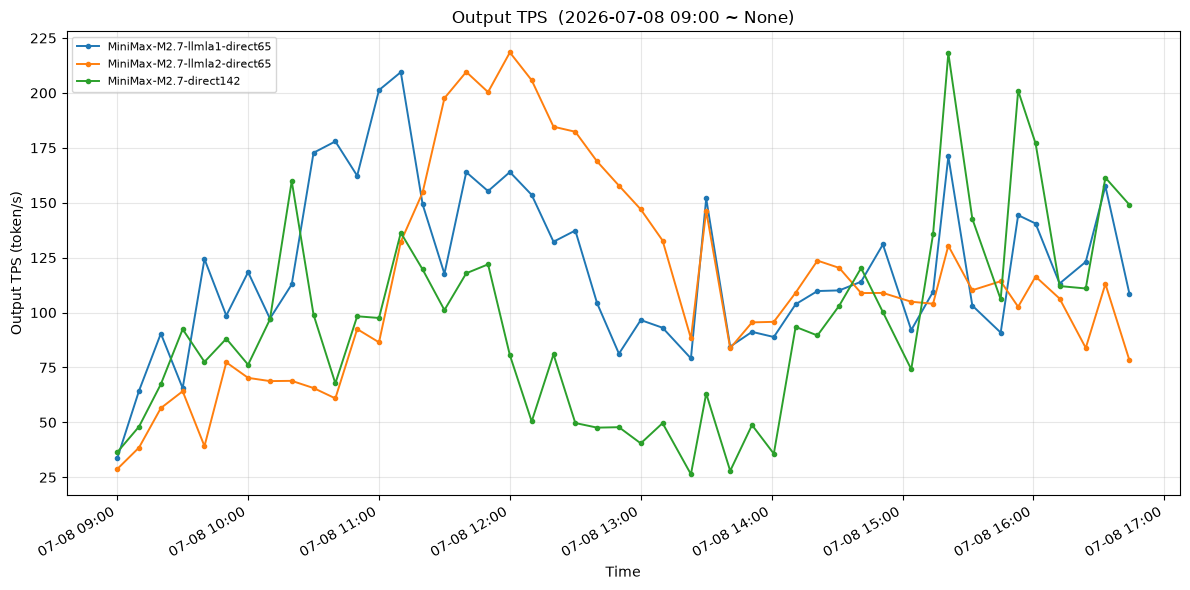

In [22]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-07-08 09:00"    # set to None for no lower bound
END   = None #"2026-06-25 16:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in tps.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):   # break across gaps
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Output TPS (token/s)")
plt.title(f"Output TPS  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean output TPS = 121.2  (n=47)
[ok] MiniMax-M2.7-llmla2-direct65: mean output TPS = 113.9  (n=47)
[ok] MiniMax-M2.7-direct142: mean output TPS = 94.6  (n=47)


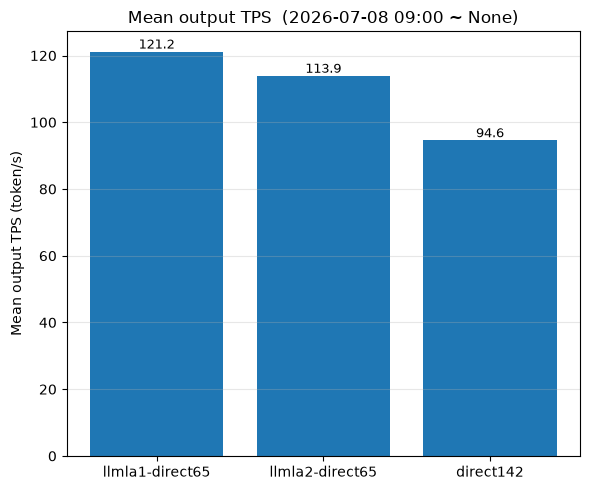

In [23]:
# ============================================================
# Cell 2 — TPS bar chart: mean output TPS per model over the window
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean output TPS = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean output TPS (token/s)")
plt.title(f"Mean output TPS  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 47 points
[ok] MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 47 points
[ok] MiniMax-M2.7-direct142 -> original: 47 points


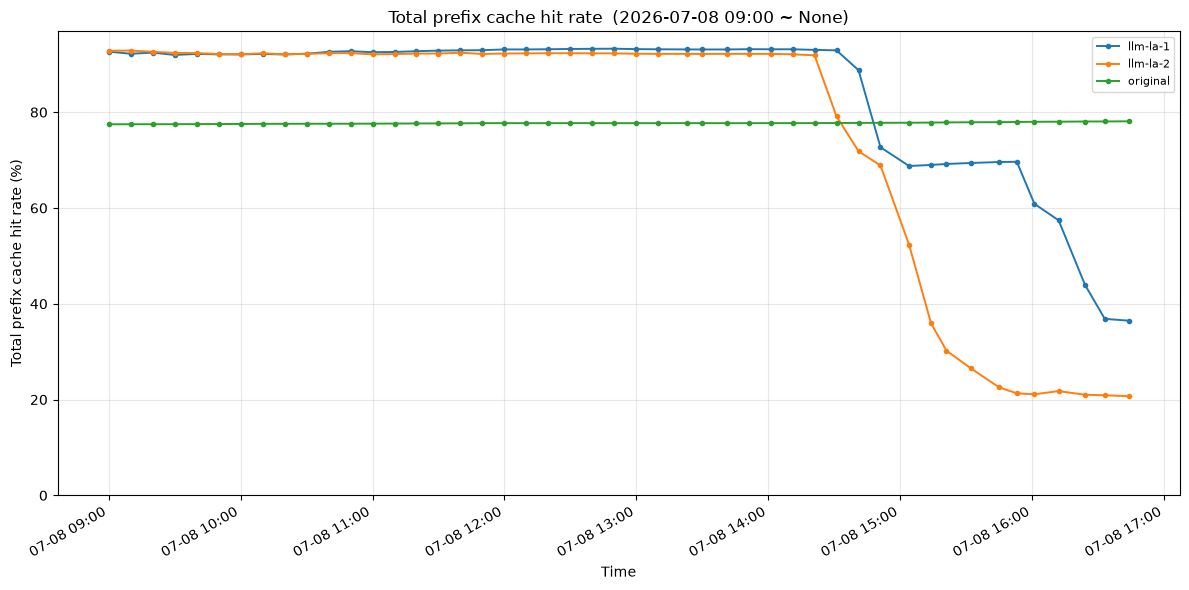

In [24]:
# ============================================================
# Cell 3 — Total prefix cache hit rate line chart over a time window
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None    # set to None for no upper bound
LABELS = ["llm-la-1", "llm-la-2", "original"]   # display labels, in MODELS order
start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)
plt.figure(figsize=(12, 6))
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=disp if c is None else None)
        c = line.get_color()
    print(f"[ok] {m} -> {disp}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("Total prefix cache hit rate (%)")
plt.title(f"Total prefix cache hit rate  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.ylim(bottom=0)
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean cache hit = 84.4%  (n=47)
[ok] MiniMax-M2.7-llmla2-direct65: mean cache hit = 75.7%  (n=47)
[ok] MiniMax-M2.7-direct142: mean cache hit = 77.7%  (n=47)


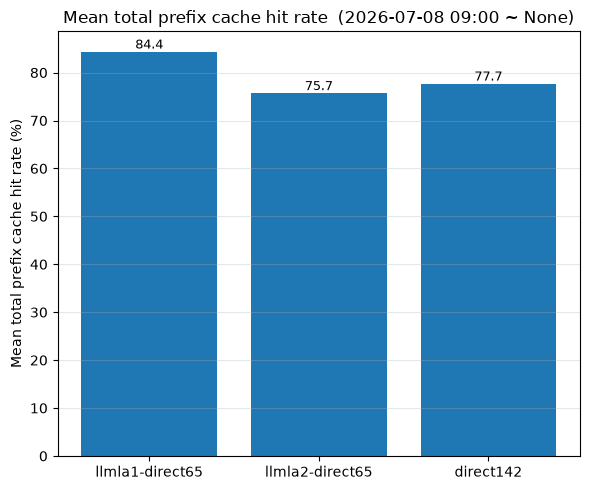

In [30]:
# ============================================================
# Cell 4 — Cache bar chart: mean total prefix cache hit rate per model
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = cache.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean cache hit = {mean:.1f}%  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean total prefix cache hit rate (%)")
plt.title(f"Mean total prefix cache hit rate  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] llm-la avg: 47 points
[ok] Original (142): 47 points
[saved] figures/tps_line_20260708_0900_to_20260708_1645.png


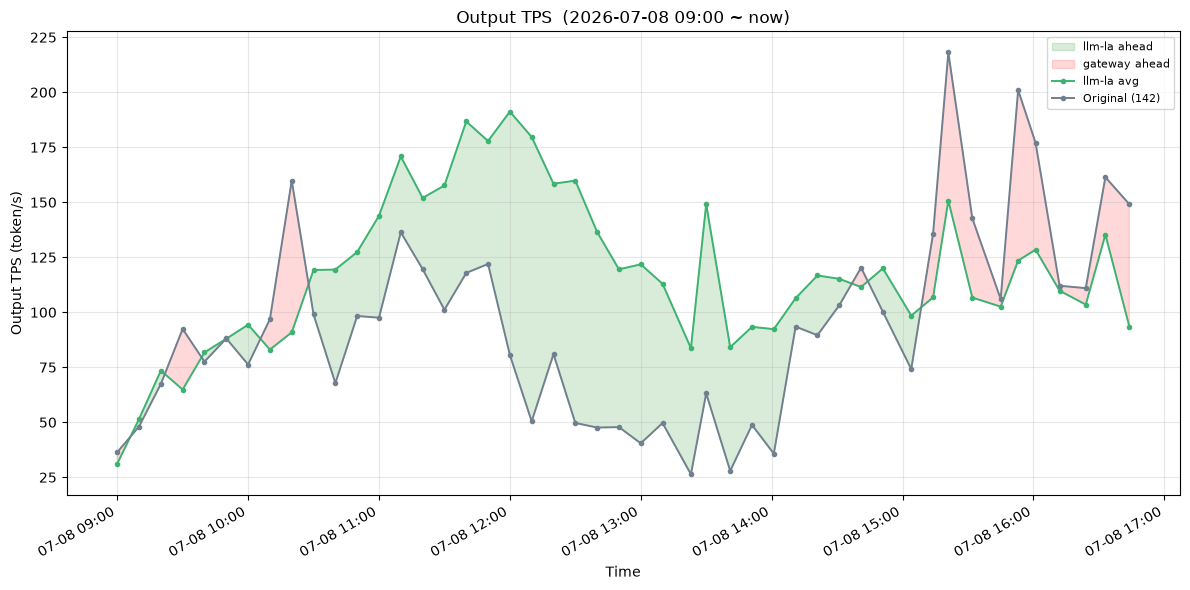

In [31]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None # "2026-06-27 16:15"  # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "Original (142)",
}

import os
import numpy as np
from datetime import datetime

# ── compute per-timestamp mean of the two llm-la series ───
la1 = tps.get("MiniMax-M2.7-llmla1-direct65", {})
la2 = tps.get("MiniMax-M2.7-llmla2-direct65", {})
boom_raw = tps.get("MiniMax-M2.7-direct142", {})

common_ts = sorted(set(la1) & set(la2))
la_mean = {ts: (la1[ts] + la2[ts]) / 2 for ts in common_ts}

# ── align timestamps for fill_between ─────────────────────
all_ts   = sorted(set(la_mean) & set(boom_raw))
xs_align = np.array(all_ts)
la_arr   = np.array([la_mean[ts]   for ts in all_ts])
bm_arr   = np.array([boom_raw[ts]  for ts in all_ts])

PLOT = {
    "llm-la avg":   la_mean,
    "Original (142)": boom_raw,
}
COLORS = {
    "llm-la avg":   "mediumseagreen",
    "Original (142)": "slategray",
}

fig, ax = plt.subplots(figsize=(12, 6))

# ── shaded regions ────────────────────────────────────────
ax.fill_between(xs_align, la_arr, bm_arr,
                where=(la_arr >= bm_arr),
                interpolate=True,
                color="green", alpha=0.15, label="llm-la ahead")
ax.fill_between(xs_align, la_arr, bm_arr,
                where=(la_arr < bm_arr),
                interpolate=True,
                color="red", alpha=0.15, label="gateway ahead")

# ── lines ─────────────────────────────────────────────────
for label, pts in PLOT.items():
    if not pts:
        print(f"[warn] {label}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                        color=COLORS.get(label, c),
                        label=label if c is None else None)
        c = line.get_color()
    print(f"[ok] {label}: {len(pts)} points")

ax.set_xlabel("Time"); ax.set_ylabel("Output TPS (token/s)")
ax.set_title(f"Output TPS  ({START} ~ {END or 'now'})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate(); plt.tight_layout()

# ── save ──────────────────────────────────────────────────
def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")

start_str = _fmt(start, START.replace(" ", "_").replace(":", ""))
end_str   = _fmt(end,   datetime.now().strftime("%Y%m%d_%H%M"))

os.makedirs("figures", exist_ok=True)
out_path = f"figures/tps_line_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 47 points, mean=121.2
[ok] MiniMax-M2.7-llmla2-direct65: 47 points, mean=113.9
[ok] MiniMax-M2.7-direct142: 47 points, mean=94.6
[saved] figures/tps_bar_20260708_0900_to_20260708_1645.png

── TPS summary ──
  llm-la-1         121.2 tok/s  (+28.1% vs boom gateway)
  llm-la-2         113.9 tok/s  (+20.4% vs boom gateway)
  original (142)    94.6 tok/s
  avg              117.6 tok/s  (+24.3% vs boom gateway)


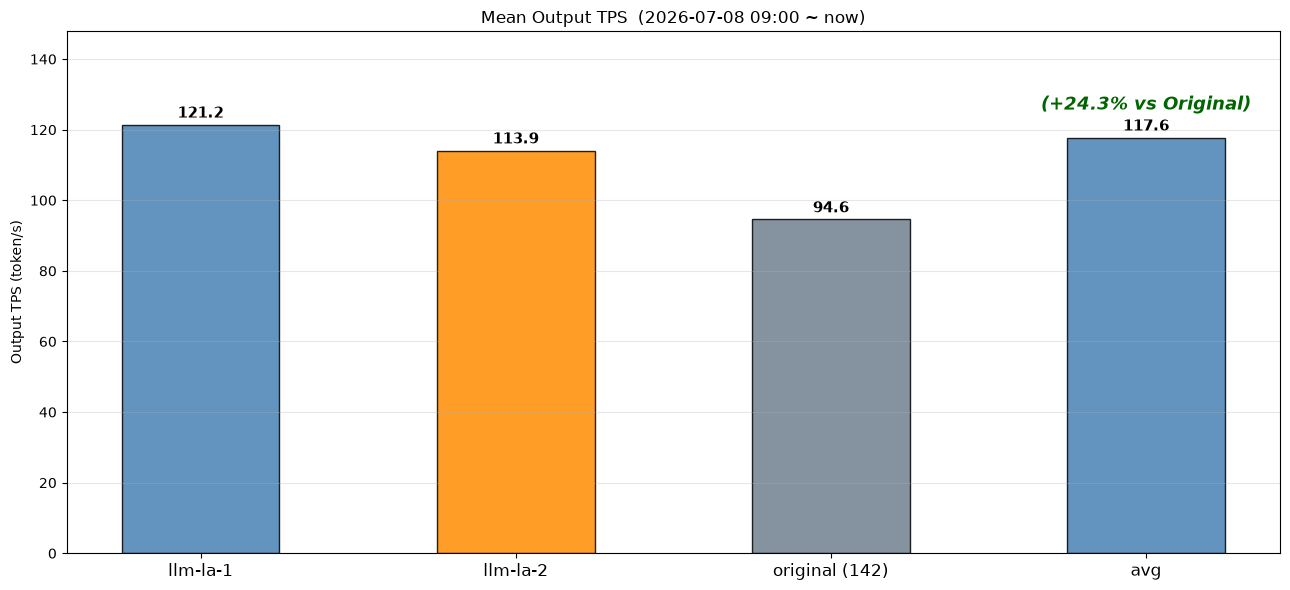

In [32]:
# ============================================================
# Cell 1 — TPS bar chart over a time window
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None # "2026-06-27 16:15"  # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "original (142)",
}

import numpy as np
from datetime import datetime
import os

# ── collect means ──────────────────────────────────────────
raw_means = {}
for m, label in DISPLAY.items():
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data in window")
        continue
    vals = list(pts.values())
    raw_means[label] = np.mean(vals)
    print(f"[ok] {m}: {len(vals)} points, mean={raw_means[label]:.1f}")

# ── inject average column ─────────────────────────────────
llmla_vals = [raw_means[k] for k in ("llm-la-1", "llm-la-2") if k in raw_means]
if len(llmla_vals) == 2:
    raw_means["avg"] = np.mean(llmla_vals)

# ── compute % improvement over boom gateway ────────────────
boom = raw_means.get("original (142)")
pct_improvement = {}
if boom and boom > 0:
    for label in ("llm-la-1", "llm-la-2", "avg"):
        if label in raw_means:
            pct_improvement[label] = (raw_means[label] - boom) / boom * 100

# ── plot ───────────────────────────────────────────────────
COLORS = {
    "llm-la-1":    "steelblue",
    "llm-la-2":    "darkorange",
    "llm avg":         "mediumseagreen",
    "original (142)": "slategray",
}

labels = list(raw_means.keys())
means  = list(raw_means.values())
colors = [COLORS.get(l, "steelblue") for l in labels]

fig, ax = plt.subplots(figsize=(13, 6))
x    = np.arange(len(labels))
bars = ax.bar(x, means, width=0.5,
              color=colors, alpha=0.85, edgecolor="black")

for bar, label, mean in zip(bars, labels, means):
    cx = bar.get_x() + bar.get_width() / 2
    ax.text(cx, bar.get_height() * 1.01,
            f"{mean:.1f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
    if label == "avg" and label in pct_improvement:
        pct = pct_improvement[label]
        sign = "+" if pct >= 0 else ""
        ax.text(cx, bar.get_height() * 1.01 + ax.get_ylim()[1] * 0.045,
                f"({sign}{pct:.1f}% vs Original)",
                ha="center", va="bottom", fontsize=13, fontweight="bold",
                color="darkgreen" if pct >= 0 else "crimson",
                fontstyle="italic")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Output TPS (token/s)")
ax.set_ylim(bottom=0, top=max(means) * 1.22)
ax.set_title(f"Mean Output TPS  ({START} ~ {END or 'now'})")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()

# ── save ──────────────────────────────────────────────────
def _fmt(dt, fallback):
    """Format a datetime (or None) to a compact string for filenames."""
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")

start_str = _fmt(start, START.replace(" ", "_").replace(":", ""))
end_str   = _fmt(end,   datetime.now().strftime("%Y%m%d_%H%M"))

os.makedirs("figures", exist_ok=True)
out_path = f"figures/tps_bar_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

# ── print summary ─────────────────────────────────────────
print(f"\n── TPS summary ──")
for label, mean in raw_means.items():
    pct_str = ""
    if label in pct_improvement:
        pct = pct_improvement[label]
        pct_str = f"  ({'+' if pct>=0 else ''}{pct:.1f}% vs boom gateway)"
    print(f"  {label:<14} {mean:>7.1f} tok/s{pct_str}")

plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 47 points
[ok] MiniMax-M2.7-llmla2-direct65: 44 points
[ok] MiniMax-M2.7-direct142: 47 points


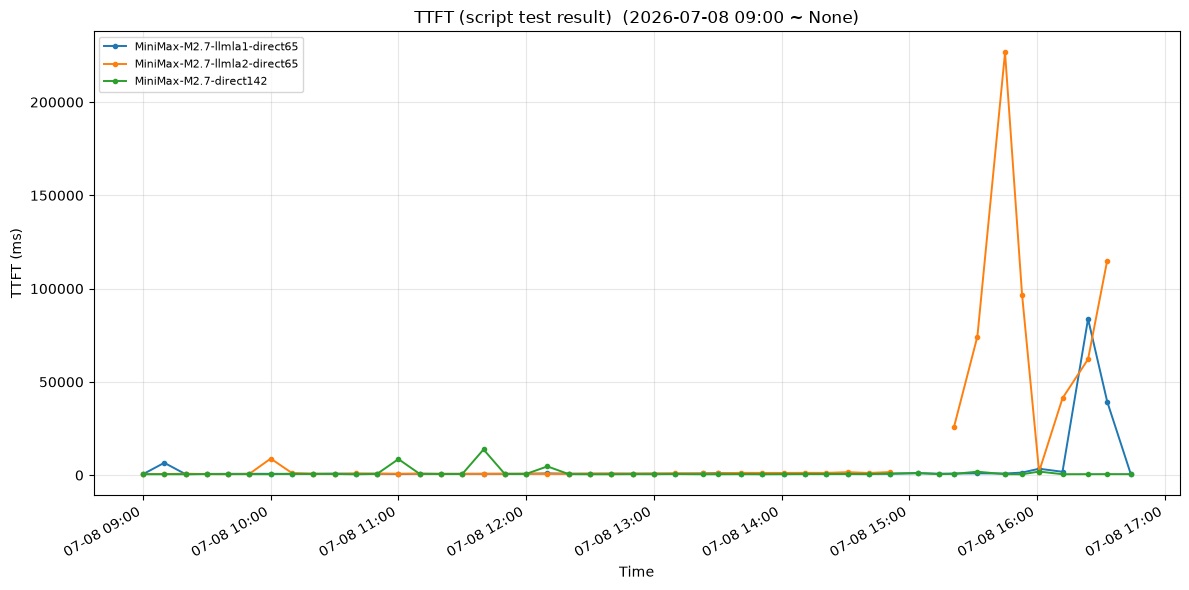

[ok] MiniMax-M2.7-llmla1-direct65: mean TTFT = 3589.3 ms  (n=47)
[ok] MiniMax-M2.7-llmla2-direct65: mean TTFT = 15555.5 ms  (n=44)
[ok] MiniMax-M2.7-direct142: mean TTFT = 1181.9 ms  (n=47)


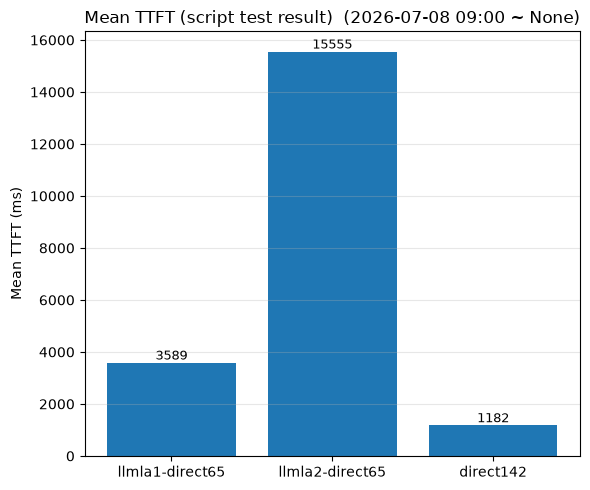

In [33]:
# ============================================================
# Cell 5 — TTFT (script test result) over a time window
# Field: identifier_metrics[model]["ttft"]  (milliseconds)
#
# NOTE: this is the `ttft` field from the data API, which is produced by the
# benchmark script (test_and_collect.py) and surfaced through /api/data.
# It is a DIRECT latency value (ms), NOT a rate -> we take the value as-is,
# no diff/time like TPS.
# CAVEAT: not yet 100% verified to equal the page's "TTFT (script test result)"
# panel free of vLLM-metrics mixing; the field name matches but the DB->API
# mapping was not value-checked. Treat as the data-API ttft field.
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None #"2026-07-02 17:00"#None  # set to None for no upper bound

def build_ttft(models):
    """Return {model: {datetime: ttft_ms}} taken directly from the ttft field."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            ttft = v.get("ttft") or []
            n = min(len(ttft), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or ttft[i] is None: continue
                series[m][ts_dt[i]] = round(ttft[i], 2)
    return series

start, end = parse_window(START), parse_window(END)
ttft = filter_window(build_ttft(MODELS), start, end)

# ---- line chart ----
plt.figure(figsize=(12, 6))
for m, pts in ttft.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("TTFT (ms)")
plt.title(f"TTFT (script test result)  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

# ---- bar chart: mean TTFT over the window ----
names, means = [], []
for m in MODELS:
    pts = ttft.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean TTFT = {mean:.1f} ms  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.0f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean TTFT (ms)")
plt.title(f"Mean TTFT (script test result)  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 48 points
[ok] MiniMax-M2.7-llmla2-direct65: 48 points
[ok] MiniMax-M2.7-direct142: 48 points


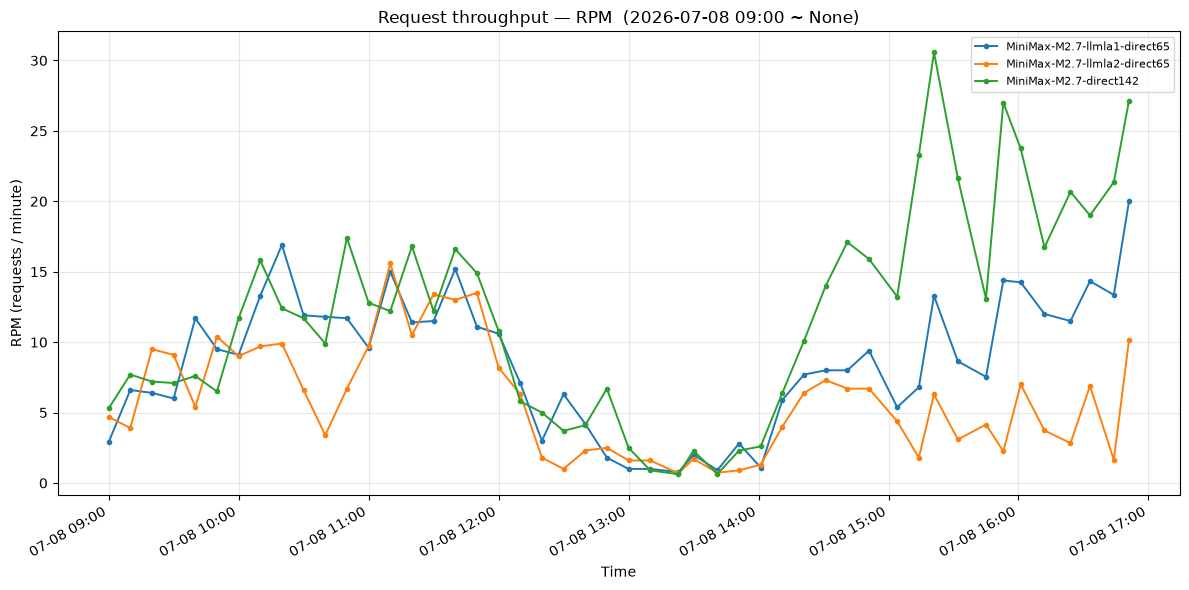

In [34]:
# ============================================================
# Cell A — RPM (requests per minute) line chart over a time window
# RPM = request_increment / actual_minutes_between_adjacent_timestamps (the request_increment is counted by the number of successfully finished requests)
# (uses the real minute span, not a fixed 10, since datapoints are 10~11 min apart)
# ============================================================succew
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

def build_rpm(models):
    """Return {model: {datetime: rpm}} = request_increment / minutes_in_window."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(1, n):                 # need previous ts for the minute span
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                if incr[i] is None: continue
                minutes = (ts_dt[i] - ts_dt[i-1]).total_seconds() / 60.0
                if minutes <= 0: continue
                series[m][ts_dt[i]] = round(incr[i] / minutes, 2)
    return series

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in rpm.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("RPM (requests / minute)")
plt.title(f"Request throughput — RPM  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean RPM = 8.6  (n=48)
[ok] MiniMax-M2.7-llmla2-direct65: mean RPM = 5.8  (n=48)
[ok] MiniMax-M2.7-direct142: mean RPM = 12.0  (n=48)


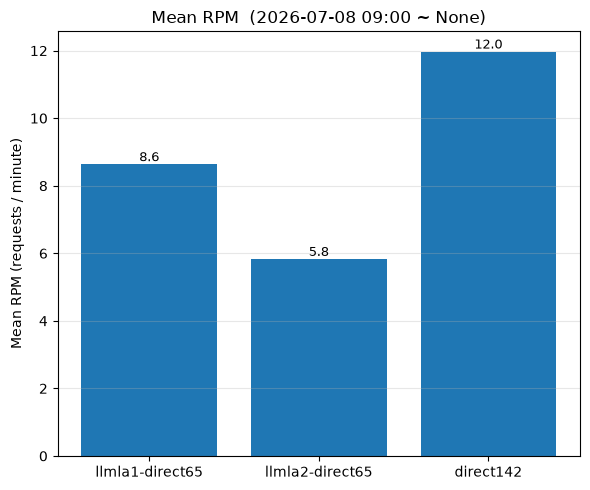

In [35]:
# ============================================================
# Cell B — RPM bar chart: mean RPM per model over the window
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = rpm.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean RPM = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean RPM (requests / minute)")
plt.title(f"Mean RPM  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()


[ok] MiniMax-M2.7-llmla1-direct65: 48 points
[ok] MiniMax-M2.7-llmla2-direct65: 48 points
[ok] MiniMax-M2.7-direct142: 48 points


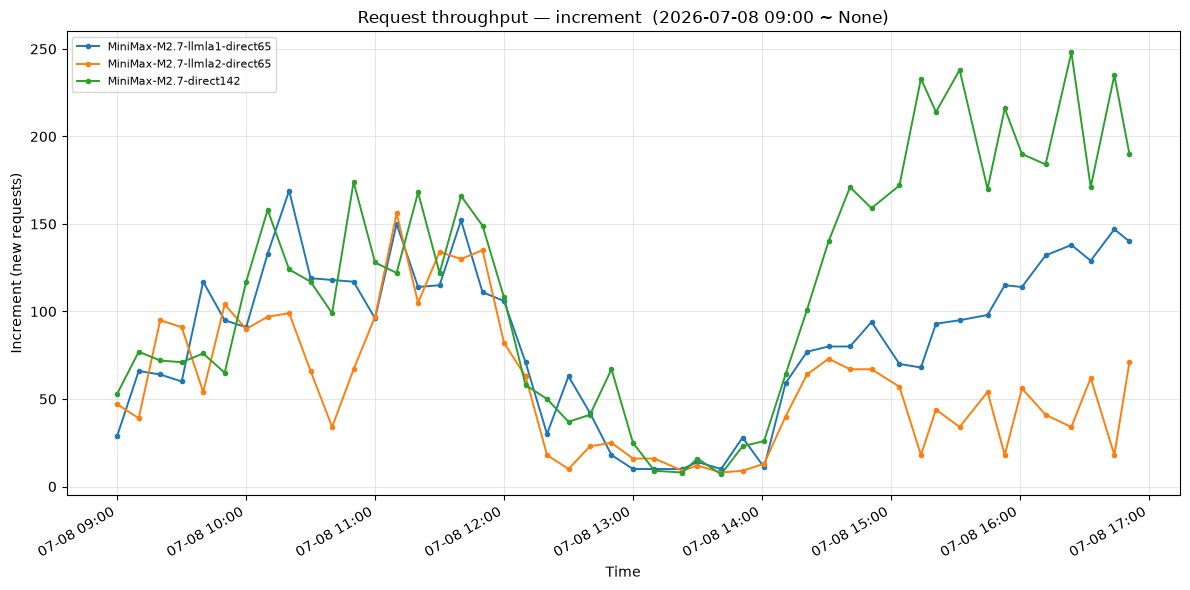

In [36]:
# ============================================================
# Cell C — Increment (new requests per datapoint) line chart over a window
# Source: identifier_metrics[model]["request_increment"] (raw, taken as-is)
# ============================================================
START = "2026-07-08 09:00"     # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

def build_increment(models):
    """Return {model: {datetime: request_increment}} taken directly."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or incr[i] is None: continue
                series[m][ts_dt[i]] = incr[i]
    return series

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in inc.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Increment (new requests)")
plt.title(f"Request throughput — increment  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean increment = 20.7  (n=260)
[ok] MiniMax-M2.7-llmla2-direct65: mean increment = 24.1  (n=260)
[ok] MiniMax-M2.7-direct142: mean increment = 48.8  (n=260)


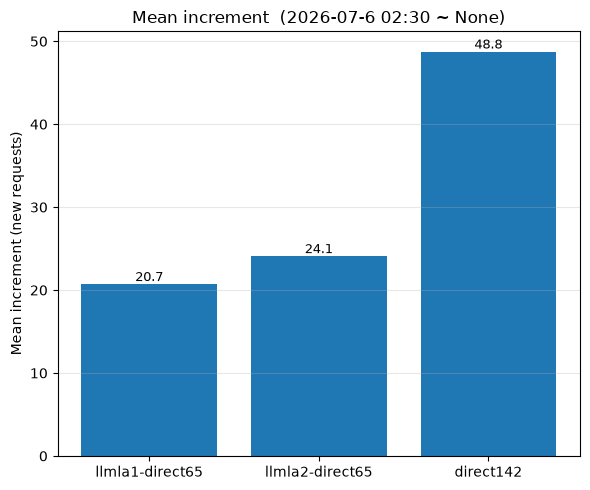

In [32]:
# ============================================================
# Cell D — Increment bar chart: mean increment per model over the window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = inc.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean increment = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean increment (new requests)")
plt.title(f"Mean increment  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[79]

exp 79 time range:
  first: 2026-07-07 11:02:40.368959+00:00
  last:  2026-07-08 08:51:21.875378+00:00
  span:  0 days 21:48:41.506419
  after crop: 26100 rows  [2026-07-07 11:02:40.368959+00:00 ~ 2026-07-08 08:51:21.875378+00:00]
[ok] exp 79 llm-la-1: 2610 points, mean=2581.14
[ok] exp 79 llm-la-2: 2610 points, mean=3106.12
[saved] figures/prefix_cache_hits_per_sec_20260707_1102_to_20260708_0851.png


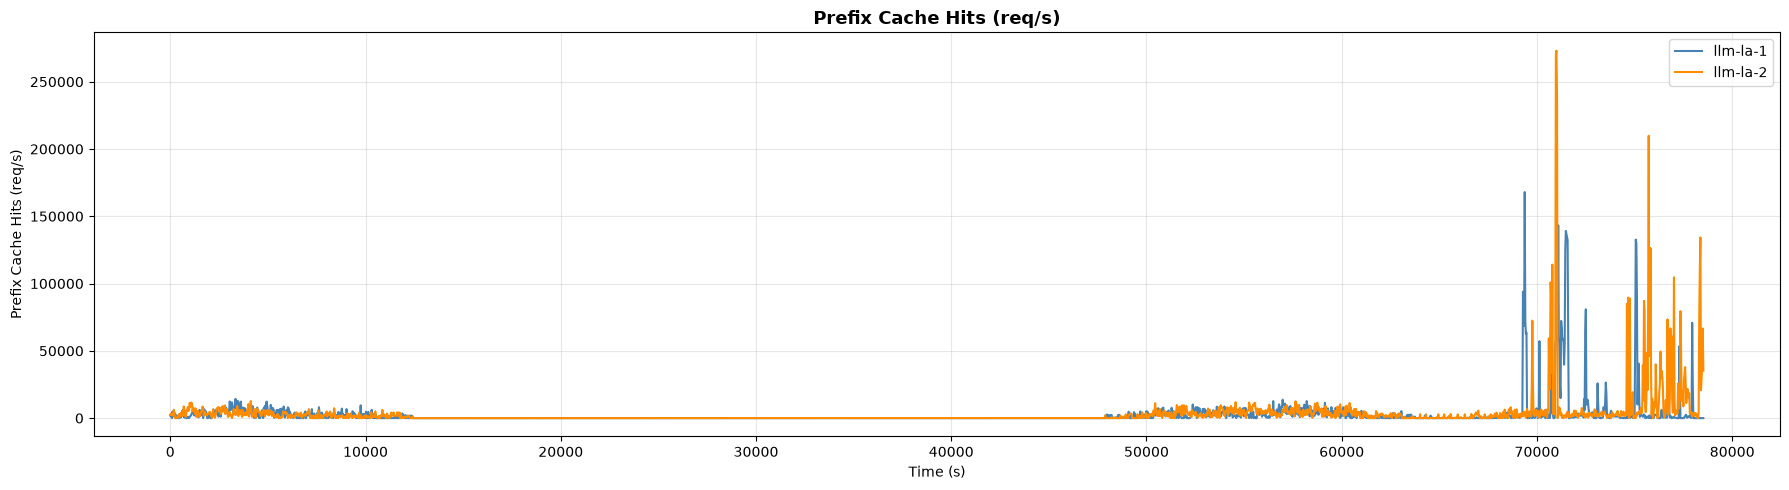

In [38]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os
import numpy as np
from datetime import datetime

# ---- choose experiments ----
experiments = [79]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)

# ── optional time crop (set to None to disable) ───────────
T_START = None
T_END   = None

# ── worker groups to average ──────────────────────────────
GROUPS = {
    "llm-la-1": ["server1", "server2"],
    "llm-la-2": ["server3", "server4"],
}
GROUP_COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
}

METRIC_LABELS = {
    "requests_running":             "Requests Running",
    "requests_waiting":             "Requests Waiting",
    "gen_tokens_per_sec":           "Generation Throughput (tok/s)",
    "prefill_tokens_per_sec":       "Prefill Throughput (tok/s)",
    "kv_cache_usage_perc":          "KV Cache Usage (%)",
    "request_success_per_sec":      "Request Success Rate (req/s)",
    "preemptions_per_sec":          "Preemptions (req/s)",
    "ttft_seconds_avg":             "Avg TTFT (s)",
    "tpot_seconds_avg":             "Avg TPOT (s)",
    "e2e_latency_seconds_avg":      "Avg E2E Latency (s)",
    "prefix_cache_hit_rate":        "Prefix Cache Hit Rate",
    "prefix_cache_hits_per_sec":    "Prefix Cache Hits (req/s)",
    "prefix_cache_queries_per_sec": "Prefix Cache Queries (req/s)",
    "sidecar_queue_length":         "Sidecar Queue Length",
}


def _port_of_instance(inst: str):
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]

def _group_mean(df, slots, metric):
    sub = df[df["server_slot"].isin(slots)].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    return (
        sub.groupby("t_rel_s")[metric]
        .mean()
        .sort_index()
    )

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

def _fmt(dt, fallback):
    if dt is None or pd.isna(dt):
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0
crop_start_ts = crop_end_ts = None

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"exp {exp_id}: no data"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    print(f"\nexp {exp_id} time range:")
    print(f"  first: {prom['ts'].min()}")
    print(f"  last:  {prom['ts'].max()}")
    print(f"  span:  {prom['ts'].max() - prom['ts'].min()}")

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]

    if prom.empty:
        raise ValueError(
            f"exp {exp_id}: crop window [{T_START}, {T_END}] excluded ALL rows "
            f"(experiment lies outside this range) — check T_START/T_END"
        )

    print(f"  after crop: {len(prom)} rows  [{prom['ts'].min()} ~ {prom['ts'].max()}]")

    crop_start_ts = prom["ts"].min()
    crop_end_ts   = prom["ts"].max()

    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

metric_label = METRIC_LABELS.get(metric, metric.replace("_", " ").title())

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for group_name, slots in GROUPS.items():
        series = _group_mean(df, slots, metric)
        if series.empty:
            print(f"[warn] {group_name}: no data")
            continue
        ax.plot(
            series.index,
            series.values,
            color=GROUP_COLORS[group_name],
            linewidth=1.5,
            label=group_name,
        )
        print(f"[ok] exp {exp_id} {group_name}: {len(series)} points, mean={series.mean():.2f}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── save ──────────────────────────────────────────────────
start_str = _fmt(crop_start_ts, "start")
end_str   = _fmt(crop_end_ts,   datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs("figures", exist_ok=True)
out_path = f"figures/{metric}_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

[79]

exp 79 time range:
  first: 2026-07-07 11:02:40.368959+00:00
  last:  2026-07-08 08:55:22.588788+00:00
  span:  0 days 21:52:42.219829
  after crop: 26180 rows  [2026-07-07 11:02:40.368959+00:00 ~ 2026-07-08 08:55:22.588788+00:00]
[ok] exp 79 llm-la-1: 2618 points, mean=2573.26
[ok] exp 79 llm-la-2: 2618 points, mean=3128.02
[saved] figures/prefix_cache_hits_per_sec_20260707_1102_to_20260708_0855.png


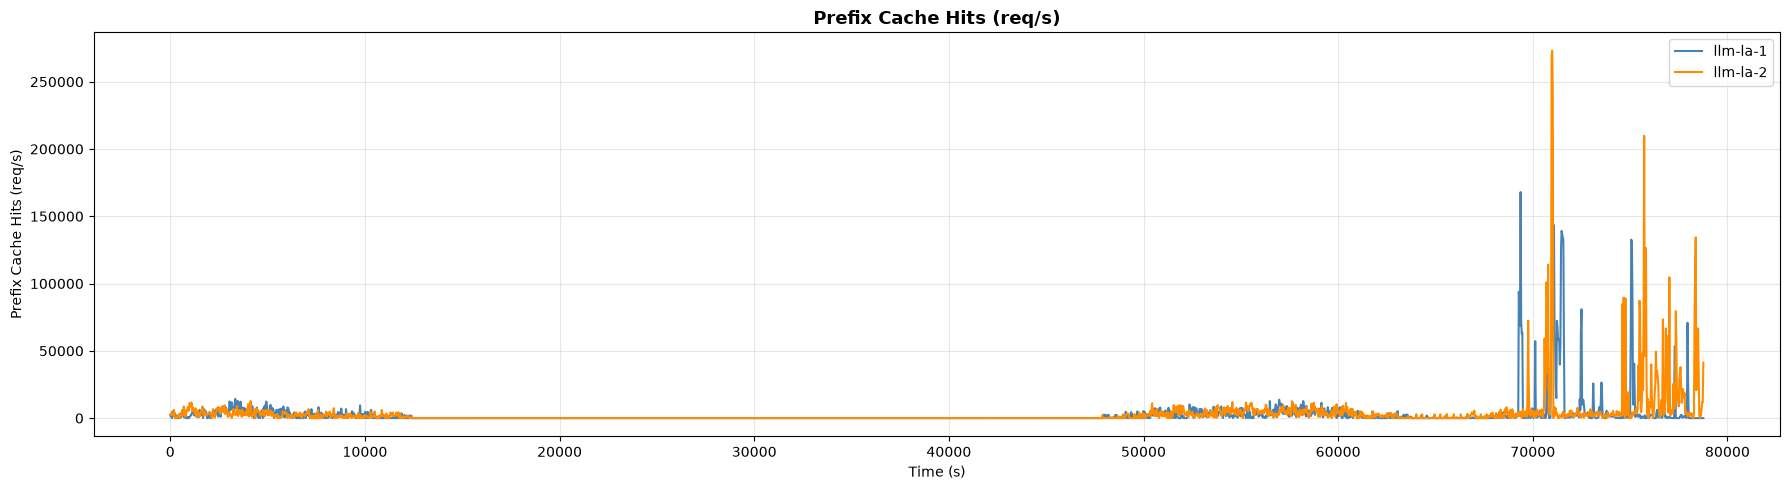

In [39]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os
import numpy as np
from datetime import datetime

# ---- choose experiments ----
experiments = [79]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)

# ── optional time crop (set to None to disable) ───────────
T_START = None
T_END   = None #"2026-06-27 02:21:08.136732+00:00"

# ── worker groups to average ──────────────────────────────
GROUPS = {
    "llm-la-1": ["server1", "server2"],
    "llm-la-2": ["server3", "server4"],
}
GROUP_COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
}

METRIC_LABELS = {
    "requests_running":             "Requests Running",
    "requests_waiting":             "Requests Waiting",
    "gen_tokens_per_sec":           "Generation Throughput (tok/s)",
    "prefill_tokens_per_sec":       "Prefill Throughput (tok/s)",
    "kv_cache_usage_perc":          "KV Cache Usage (%)",
    "request_success_per_sec":      "Request Success Rate (req/s)",
    "preemptions_per_sec":          "Preemptions (req/s)",
    "ttft_seconds_avg":             "Avg TTFT (s)",
    "tpot_seconds_avg":             "Avg TPOT (s)",
    "e2e_latency_seconds_avg":      "Avg E2E Latency (s)",
    "prefix_cache_hit_rate":        "Prefix Cache Hit Rate",
    "prefix_cache_hits_per_sec":    "Prefix Cache Hits (req/s)",
    "prefix_cache_queries_per_sec": "Prefix Cache Queries (req/s)",
    "sidecar_queue_length":         "Sidecar Queue Length",
}


def _port_of_instance(inst: str):
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]

def _group_mean(df, slots, metric):
    sub = df[df["server_slot"].isin(slots)].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    return (
        sub.groupby("t_rel_s")[metric]
        .mean()
        .sort_index()
    )

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0
crop_start_ts = crop_end_ts = None

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"exp {exp_id}: no data"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    print(f"\nexp {exp_id} time range:")
    print(f"  first: {prom['ts'].min()}")
    print(f"  last:  {prom['ts'].max()}")
    print(f"  span:  {prom['ts'].max() - prom['ts'].min()}")

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]
    print(f"  after crop: {len(prom)} rows  [{prom['ts'].min()} ~ {prom['ts'].max()}]")

    crop_start_ts = prom["ts"].min()
    crop_end_ts   = prom["ts"].max()

    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

metric_label = METRIC_LABELS.get(metric, metric.replace("_", " ").title())

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for group_name, slots in GROUPS.items():
        series = _group_mean(df, slots, metric)
        if series.empty:
            print(f"[warn] {group_name}: no data")
            continue
        ax.plot(
            series.index,
            series.values,
            color=GROUP_COLORS[group_name],
            linewidth=1.5,
            label=group_name,
        )
        print(f"[ok] exp {exp_id} {group_name}: {len(series)} points, mean={series.mean():.2f}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── save ──────────────────────────────────────────────────
start_str = _fmt(crop_start_ts, "start")
end_str   = _fmt(crop_end_ts,   datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs("figures", exist_ok=True)
out_path = f"figures/{metric}_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

[79]

exp 79 time range:
  first: 2026-07-07 11:02:40.368959+00:00
  last:  2026-07-08 08:55:52.890985+00:00
  span:  0 days 21:53:12.522026
[ok] Admission RPS: 2619 points, mean=0.12
[saved] figures/router_admission_rps_20260707_1102_to_20260708_0855.png


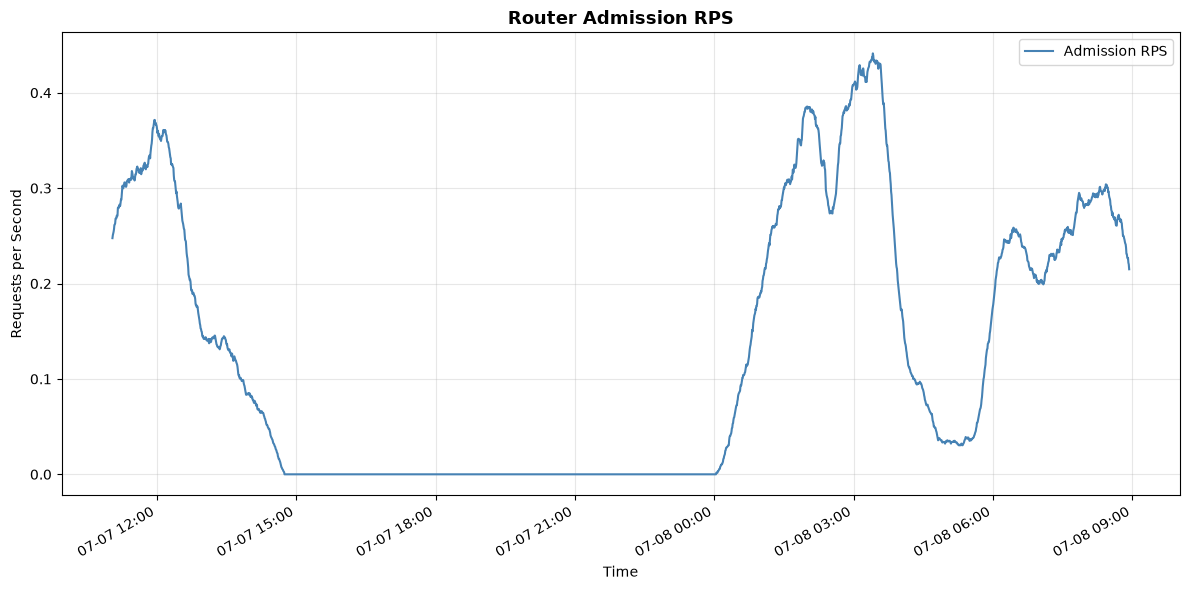

In [40]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from datetime import datetime

# ---- choose experiments ----
experiments = [79]
print(experiments)

METRICS = {
    "router_admission_rps": "Admission RPS",
}
COLORS = {
    "router_admission_rps": "steelblue",
}

# ── optional time crop (set to None to disable) ───────────
T_START = None
T_END   = None

agg_mode      = "sum"  # "sum" or "mean"
smooth_window = 60     # rolling average window in samples; set to 1 to disable


def _port_of_instance(inst: str):
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

crop_start_ts = crop_end_ts = None

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"exp {exp_id}: no data"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    print(f"\nexp {exp_id} time range:")
    print(f"  first: {prom['ts'].min()}")
    print(f"  last:  {prom['ts'].max()}")
    print(f"  span:  {prom['ts'].max() - prom['ts'].min()}")

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]

    df = _subset_by_port(prom, 8080)
    if df.empty:
        print(f"exp {exp_id}: no router rows"); continue

    crop_start_ts = df["ts"].min()
    crop_end_ts   = df["ts"].max()

    for metric, label in METRICS.items():
        if metric not in df.columns:
            print(f"[warn] {metric} not found"); continue

        # group by actual timestamp instead of t_rel_s
        if agg_mode == "sum":
            series = df.groupby("ts")[metric].sum(min_count=1)
        else:
            series = df.groupby("ts")[metric].mean()

        series = series.sort_index()
        smoothed = series.rolling(window=smooth_window, center=True, min_periods=1).mean()

        ax.plot(
            smoothed.index,
            smoothed.values,
            color=COLORS[metric],
            linewidth=1.5,
            label=label,
        )
        print(f"[ok] {label}: {len(series)} points, mean={series.mean():.2f}")

ax.set_xlabel("Time")
ax.set_ylabel("Requests per Second")
ax.set_title("Router Admission RPS", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()

# ── save ──────────────────────────────────────────────────
start_str = _fmt(crop_start_ts, "start")
end_str   = _fmt(crop_end_ts,   datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs("figures", exist_ok=True)
out_path = f"figures/router_admission_rps_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

[79]
exp 79: 9740 rows after crop  [2026-07-08 01:00:21.933505+00:00 ~ 2026-07-08 09:08:25.208330+00:00]


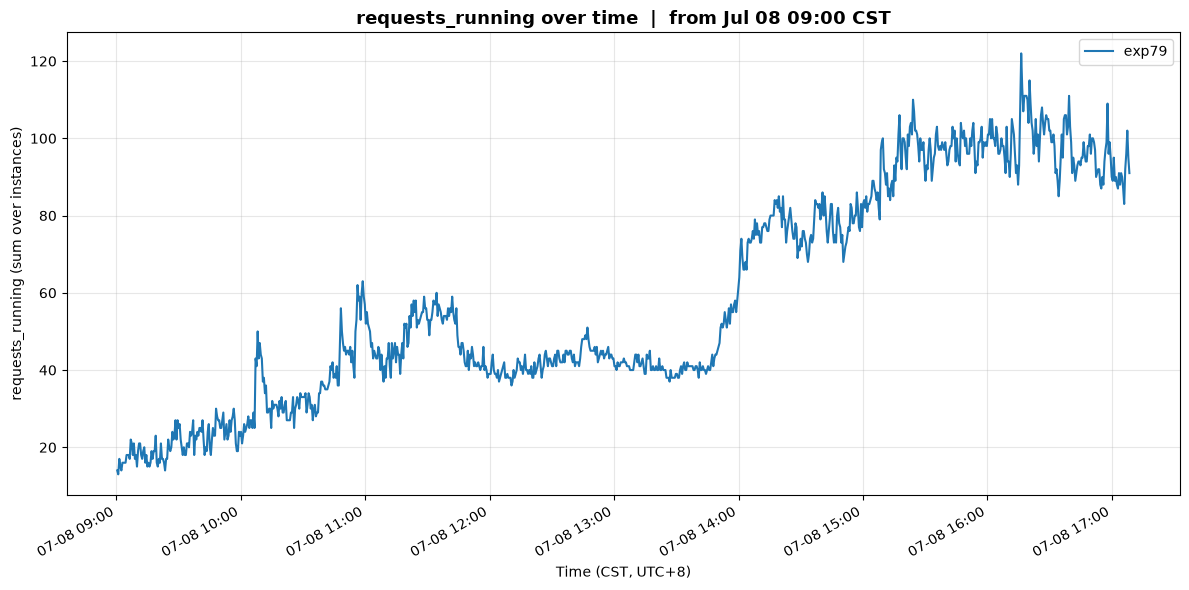

In [50]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from zoneinfo import ZoneInfo
# ---- choose experiments ----
experiments = [79]
print(experiments)
# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# ── time crop (北京时间 +08:00) ───────────────────────────
T_START = "2026-07-08 09:00+08:00"   # 北京 7/8 09:00 == UTC 01:00
T_END   = None                        # 到现在（不设上界）
TZ_DISPLAY = ZoneInfo("Asia/Shanghai")  # x 轴显示用时区
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts
fig, ax = plt.subplots(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]
    print(f"exp {exp_id}: {len(prom)} rows after crop  [{prom['ts'].min()} ~ {prom['ts'].max()}]")
    # group by actual timestamp
    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("ts")[metric].mean()
        y_label = f"{metric} (mean over instances)"
    ax.plot(series.index, series.values, label=f"exp{exp_id}")
ax.set_xlabel("Time (CST, UTC+8)")
ax.set_ylabel(y_label)
ax.set_title(f"{metric} over time  |  from Jul 08 09:00 CST", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
# ── x 轴刻度按北京时间渲染 ──
ax.xaxis.set_major_locator(mdates.AutoDateLocator(tz=TZ_DISPLAY))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=TZ_DISPLAY))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

[79]
exp 79: 9700 rows after crop  [2026-07-08 01:00:21.933505+00:00 ~ 2026-07-08 09:06:24.852236+00:00]


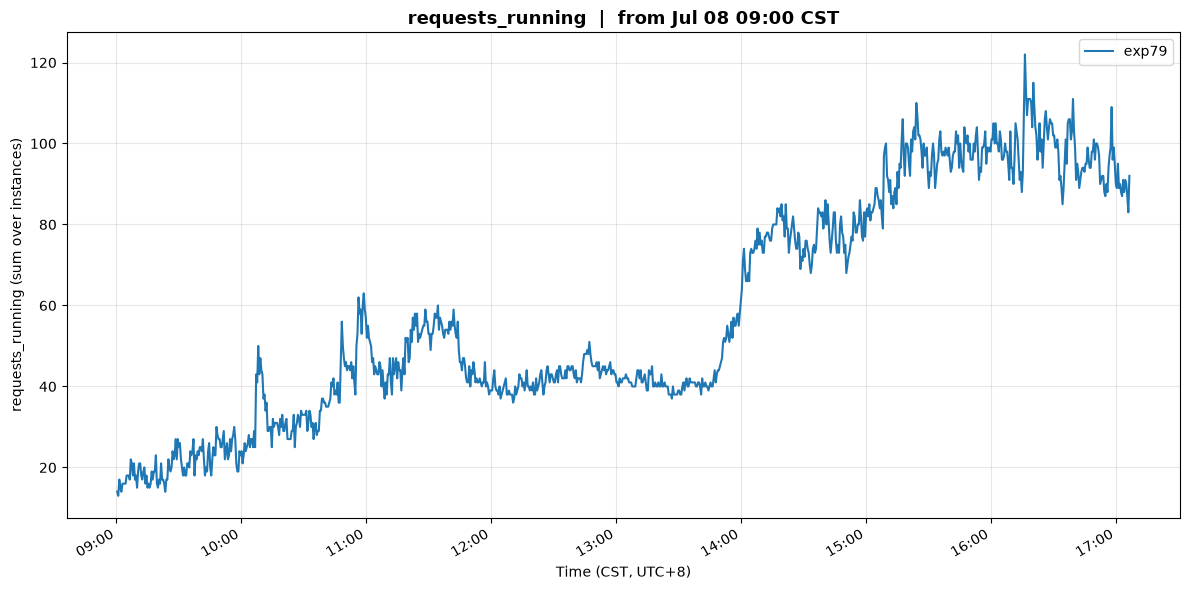

In [48]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from zoneinfo import ZoneInfo
# ---- choose experiments ----
experiments = [79]
print(experiments)
# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# ── time crop (北京时间 +08:00) ───────────────────────────
T_START = "2026-07-08 09:00+08:00"   # 北京 7/8 09:00 == UTC 01:00
T_END   = None                        # 到现在（不设上界）
TZ_DISPLAY = ZoneInfo("Asia/Shanghai")  # x 轴显示用时区
# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts
fig, ax = plt.subplots(figsize=(12, 6))
for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue
    prom = prom.sort_values("ts").reset_index(drop=True)
    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]
    print(f"exp {exp_id}: {len(prom)} rows after crop  [{prom['ts'].min()} ~ {prom['ts'].max()}]")
    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("ts")[metric].mean()
        y_label = f"{metric} (mean over instances)"
    ax.plot(series.index, series.values, label=f"exp{exp_id}")
ax.set_xlabel("Time (CST, UTC+8)")
ax.set_ylabel(y_label)
ax.set_title(f"{metric}  |  from Jul 08 09:00 CST", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
# ── x 轴刻度按北京时间渲染（关键：给 formatter/locator 指定 tz）──
ax.xaxis.set_major_locator(mdates.AutoDateLocator(tz=TZ_DISPLAY))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=TZ_DISPLAY))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

[peak] exp79: requests_running max = 122 at 2026-07-08 16:16:15.081947
[ok] MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 50 points
[ok] MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 50 points
[ok] MiniMax-M2.7-direct142 -> original: 50 points
[mark] vertical line at 2026-07-08 14:30:00


/tmp/ipykernel_2749368/1044065994.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[saved] figures/requests_running_prefix_cache_hit_rate_20260708-0900_20260708-1715.png


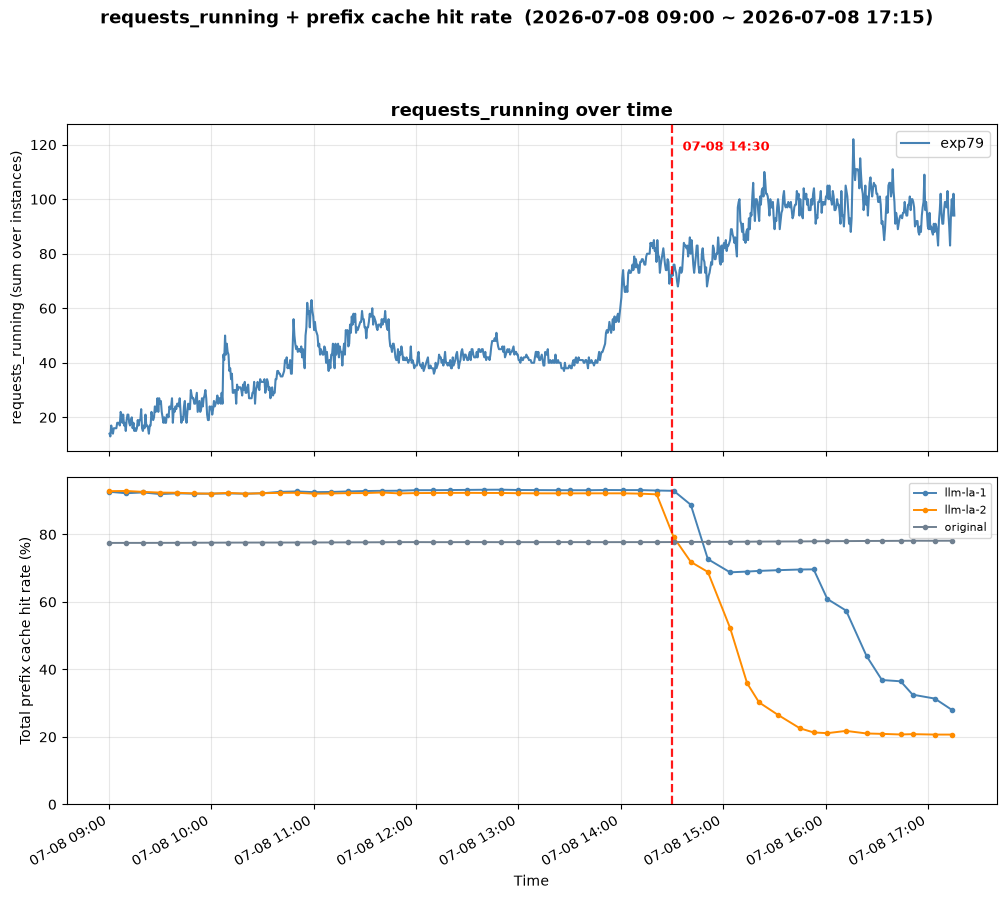

In [52]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ============================================================
# Combined: prom metric (top) + prefix cache hit rate (bottom)
#   prom timestamps  = UTC  -> converted to China
#   cache timestamps = China wall-clock (Asia/Shanghai)
# ============================================================

# ---- top panel config (prom metric) ----
experiments = [79]
metric = "requests_running"

agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

# ---- bottom panel config (prefix cache hit rate) ----
START  = "2026-07-08 09:00"   # 北京墙上时钟 7/8 09:00
END    = None
LABELS = ["llm-la-1", "llm-la-2", "original"]

# ---- timezone config ----
PROM_TZ  = "UTC"
CACHE_TZ = "Asia/Shanghai"

# ---- vertical marker config ----
# "auto"  -> place line at the requests_running peak (argmax of top series)
# or set an explicit China wall-clock string, e.g. "2026-07-3 14:40"
# MARK_TIME = "auto"

MARK_TIME = "2026-07-08 14:30"
# ---- shared color convention ----
COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
    "original": "slategray",
    "boom gateway": "slategray",
}

start, end = parse_window(START), parse_window(END)   # naive China wall-clock

def _prom_index_to_china(idx):
    """Prom index is UTC (aware or naive) -> naive China wall-clock to match cache."""
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

# track the real extent of everything plotted (China wall-clock)
data_min = None
data_max = None
def _observe(ts_index):
    global data_min, data_max
    if len(ts_index) == 0:
        return
    lo, hi = pd.Timestamp(min(ts_index)), pd.Timestamp(max(ts_index))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 10), sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# ---------------- TOP: prom metric ----------------
if agg_mode == "sum":
    y_label_top = f"{metric} (sum over instances)"
else:
    y_label_top = f"{metric} (mean over instances)"

peak_time = None   # China wall-clock timestamp of the top-series max

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
    else:
        series = prom.groupby("ts")[metric].mean()

    # UTC -> China wall-clock, then clip to the same window as the cache panel
    series.index = _prom_index_to_china(series.index)
    idx = series.index
    mask = pd.Series(True, index=idx)
    if start is not None:
        mask &= idx >= start
    if end is not None:
        mask &= idx <= end
    series = series[mask.values]
    if series.empty:
        print(f"[warn] exp{exp_id}: no {metric} points in window"); continue

    ax_top.plot(series.index, series.values, label=f"exp{exp_id}", color="steelblue")
    _observe(series.index)

    # record peak time (from the first/primary experiment)
    if peak_time is None:
        peak_time = series.idxmax()
        print(f"[peak] exp{exp_id}: {metric} max = {series.max():.3g} at {peak_time}")

ax_top.set_ylabel(y_label_top)
ax_top.set_title(f"{metric} over time", fontsize=13, fontweight="bold")
ax_top.legend(loc="upper right")
ax_top.grid(True, alpha=0.3)

# ---------------- BOTTOM: prefix cache hit rate ----------------
cache = filter_window(build_cache(MODELS), start, end)
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_bot.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                            color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] {m} -> {disp}: {len(pts)} points")

ax_bot.set_ylabel("Total prefix cache hit rate (%)")
ax_bot.set_xlabel("Time")
ax_bot.legend(fontsize=8, loc="upper right")
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(bottom=0)

# ---------------- vertical red marker ----------------
if MARK_TIME == "auto":
    mark = peak_time
else:
    mark = pd.Timestamp(MARK_TIME)   # explicit China wall-clock

if mark is not None:
    for ax in (ax_top, ax_bot):
        ax.axvline(mark, color="red", linestyle="--", linewidth=1.6, alpha=0.9, zorder=5)
    ax_top.annotate(f" {mark:%m-%d %H:%M}",
                    xy=(mark, ax_top.get_ylim()[1]),
                    xytext=(4, -12), textcoords="offset points",
                    color="red", fontsize=9, fontweight="bold",
                    va="top", ha="left")
    print(f"[mark] vertical line at {mark}")
else:
    print("[mark] no marker (peak_time unresolved and MARK_TIME='auto')")

# ---------------- title with real times (fall back to data extent) ----------------
title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max

def _fmt(ts):
    return pd.Timestamp(ts).strftime("%Y-%m-%d %H:%M") if ts is not None else "?"

# ---------------- shared x formatting ----------------
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle(f"requests_running + prefix cache hit rate  ({_fmt(title_lo)} ~ {_fmt(title_hi)})",
             fontsize=13, fontweight="bold", y=0.995)
fig.autofmt_xdate()
plt.tight_layout()

# ---------------- save ----------------
os.makedirs("figures", exist_ok=True)

def _stamp(ts, fallback):
    return pd.Timestamp(ts).strftime("%Y%m%d-%H%M") if ts is not None else fallback

fname = (f"figures/requests_running_prefix_cache_hit_rate_"
         f"{_stamp(title_lo, 'begin')}_{_stamp(title_hi, 'end')}.png")

fig.savefig(fname, dpi=150, bbox_inches="tight")
print(f"[saved] {fname}")

plt.show()

[peak] exp83: requests_running max = 114 at 2026-07-09 16:41:41.343674
[ok] cache MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 89 points
[ok] cache MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 89 points
[ok] cache MiniMax-M2.7-direct142 -> original: 85 points
[ok] ttft MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 90 points
[ok] ttft MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 90 points
[ok] ttft MiniMax-M2.7-direct142 -> original: 86 points
[mark] vertical line at 2026-07-09 14:20:00


/tmp/ipykernel_2749368/4110737633.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[saved] figures/requests_running_prefix_cache_ttft_20260709-0900_20260710-0011.png


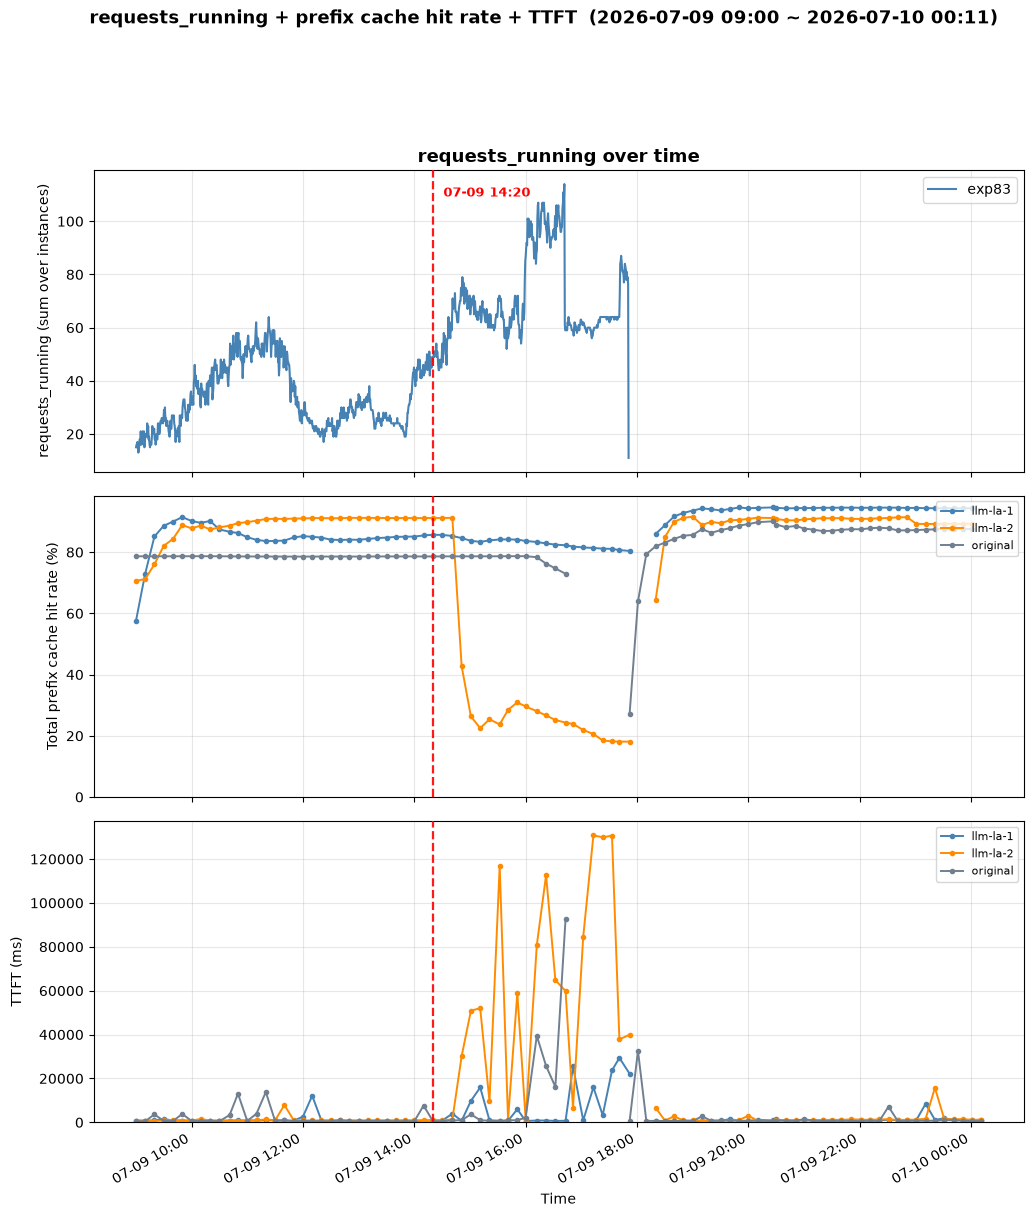

In [87]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ============================================================
# Combined: prom metric (top) + prefix cache hit rate (mid) + TTFT (bottom)
#   prom timestamps  = UTC  -> converted to China
#   cache / ttft ts  = China wall-clock (Asia/Shanghai)
# ============================================================

# ---- top panel config (prom metric) ----
experiments = [83]
metric = "requests_running"

agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

# ---- shared window (China wall-clock) ----
START  = "2026-07-09 09:00"
END    = None
LABELS = ["llm-la-1", "llm-la-2", "original"]

# ---- timezone config ----
PROM_TZ  = "UTC"
CACHE_TZ = "Asia/Shanghai"

# ---- vertical marker config ----
# "auto"  -> place line at the requests_running peak (argmax of top series)
# or set an explicit China wall-clock string, e.g. "2026-07-08 14:30"
MARK_TIME = "2026-07-09 14:20"

# ---- shared color convention ----
COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
    "original": "slategray",
    "boom gateway": "slategray",
}

start, end = parse_window(START), parse_window(END)   # naive China wall-clock

def _prom_index_to_china(idx):
    """Prom index is UTC (aware or naive) -> naive China wall-clock to match cache."""
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def build_ttft(models):
    """Return {model: {datetime: ttft_ms}} taken directly from the ttft field."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            ttft = v.get("ttft") or []
            n = min(len(ttft), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or ttft[i] is None: continue
                series[m][ts_dt[i]] = round(ttft[i], 2)
    return series

# track the real extent of everything plotted (China wall-clock)
data_min = None
data_max = None
def _observe(ts_index):
    global data_min, data_max
    if len(ts_index) == 0:
        return
    lo, hi = pd.Timestamp(min(ts_index)), pd.Timestamp(max(ts_index))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

fig, (ax_top, ax_bot, ax_ttft) = plt.subplots(
    3, 1, figsize=(12, 14), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.08})

# ---------------- TOP: prom metric ----------------
if agg_mode == "sum":
    y_label_top = f"{metric} (sum over instances)"
else:
    y_label_top = f"{metric} (mean over instances)"

peak_time = None   # China wall-clock timestamp of the top-series max

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
    else:
        series = prom.groupby("ts")[metric].mean()

    # UTC -> China wall-clock, then clip to the same window as the other panels
    series.index = _prom_index_to_china(series.index)
    idx = series.index
    mask = pd.Series(True, index=idx)
    if start is not None:
        mask &= idx >= start
    if end is not None:
        mask &= idx <= end
    series = series[mask.values]
    if series.empty:
        print(f"[warn] exp{exp_id}: no {metric} points in window"); continue

    ax_top.plot(series.index, series.values, label=f"exp{exp_id}", color="steelblue")
    _observe(series.index)

    # record peak time (from the first/primary experiment)
    if peak_time is None:
        peak_time = series.idxmax()
        print(f"[peak] exp{exp_id}: {metric} max = {series.max():.3g} at {peak_time}")

ax_top.set_ylabel(y_label_top)
ax_top.set_title(f"{metric} over time", fontsize=13, fontweight="bold")
ax_top.legend(loc="upper right")
ax_top.grid(True, alpha=0.3)

# ---------------- MIDDLE: prefix cache hit rate ----------------
cache = filter_window(build_cache(MODELS), start, end)
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] cache {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_bot.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                            color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] cache {m} -> {disp}: {len(pts)} points")

ax_bot.set_ylabel("Total prefix cache hit rate (%)")
ax_bot.legend(fontsize=8, loc="upper right")
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(bottom=0)

# ---------------- BOTTOM: TTFT (script test result) ----------------
ttft = filter_window(build_ttft(MODELS), start, end)
for i, (m, pts) in enumerate(ttft.items()):
    if not pts:
        print(f"[warn] ttft {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_ttft.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                             color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] ttft {m} -> {disp}: {len(pts)} points")

ax_ttft.set_ylabel("TTFT (ms)")
ax_ttft.set_xlabel("Time")
ax_ttft.legend(fontsize=8, loc="upper right")
ax_ttft.grid(True, alpha=0.3)
ax_ttft.set_ylim(bottom=0)

# ---------------- vertical red marker ----------------
if MARK_TIME == "auto":
    mark = peak_time
else:
    mark = pd.Timestamp(MARK_TIME)   # explicit China wall-clock

if mark is not None:
    for ax in (ax_top, ax_bot, ax_ttft):
        ax.axvline(mark, color="red", linestyle="--", linewidth=1.6, alpha=0.9, zorder=5)
    ax_top.annotate(f" {mark:%m-%d %H:%M}",
                    xy=(mark, ax_top.get_ylim()[1]),
                    xytext=(4, -12), textcoords="offset points",
                    color="red", fontsize=9, fontweight="bold",
                    va="top", ha="left")
    print(f"[mark] vertical line at {mark}")
else:
    print("[mark] no marker (peak_time unresolved and MARK_TIME='auto')")

# ---------------- title with real times (fall back to data extent) ----------------
title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max

def _fmt(ts):
    return pd.Timestamp(ts).strftime("%Y-%m-%d %H:%M") if ts is not None else "?"

# ---------------- shared x formatting ----------------
ax_ttft.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle(f"requests_running + prefix cache hit rate + TTFT  ({_fmt(title_lo)} ~ {_fmt(title_hi)})",
             fontsize=13, fontweight="bold", y=0.995)
fig.autofmt_xdate()
plt.tight_layout()

# ---------------- save ----------------
os.makedirs("figures", exist_ok=True)

def _stamp(ts, fallback):
    return pd.Timestamp(ts).strftime("%Y%m%d-%H%M") if ts is not None else fallback

fname = (f"figures/requests_running_prefix_cache_ttft_"
         f"{_stamp(title_lo, 'begin')}_{_stamp(title_hi, 'end')}.png")

fig.savefig(fname, dpi=150, bbox_inches="tight")
print(f"[saved] {fname}")

plt.show()

[grp] llm-la-1 (exp83, ids=['33']): ['7.150.6.33:8200:0', '7.150.6.33:8200:1']
[grp] llm-la-2 (exp83, ids=['218']): ['7.150.1.218:8200:0', '7.150.1.218:8200:1']
[grp] original (exp84, ids=['142']): ['7.150.2.142:8077:0', '7.150.2.142:8077:1']
[ok] requests_running / llm-la-1: 1059 pts, mean=17.436, max=32.000
[ok] requests_running / llm-la-2: 1059 pts, mean=20.276, max=32.000
[ok] requests_running / original: 930 pts, mean=11.995, max=53.000
[ok] requests_waiting / llm-la-1: 1059 pts, mean=0.262, max=3.000
[ok] requests_waiting / llm-la-2: 1059 pts, mean=1.314, max=10.000
[ok] requests_waiting / original: 930 pts, mean=1.011, max=24.000
[ok] prefix_cache_hit_rate / llm-la-1: 1059 pts, mean=58.522, max=99.979
[ok] prefix_cache_hit_rate / llm-la-2: 1059 pts, mean=47.682, max=99.946
[ok] prefix_cache_hit_rate / original: 930 pts, mean=54.873, max=99.962
[ok] ext_prefix_cache_hit_rate / llm-la-1: 1059 pts, mean=28.092, max=99.569
[ok] ext_prefix_cache_hit_rate / llm-la-2: 1059 pts, mean=39

/tmp/ipykernel_2749368/135851240.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.autofmt_xdate(); plt.tight_layout()


[saved] figures/multi_metrics_running_hitrate_ttft_20260709-0900_20260709-1750.png


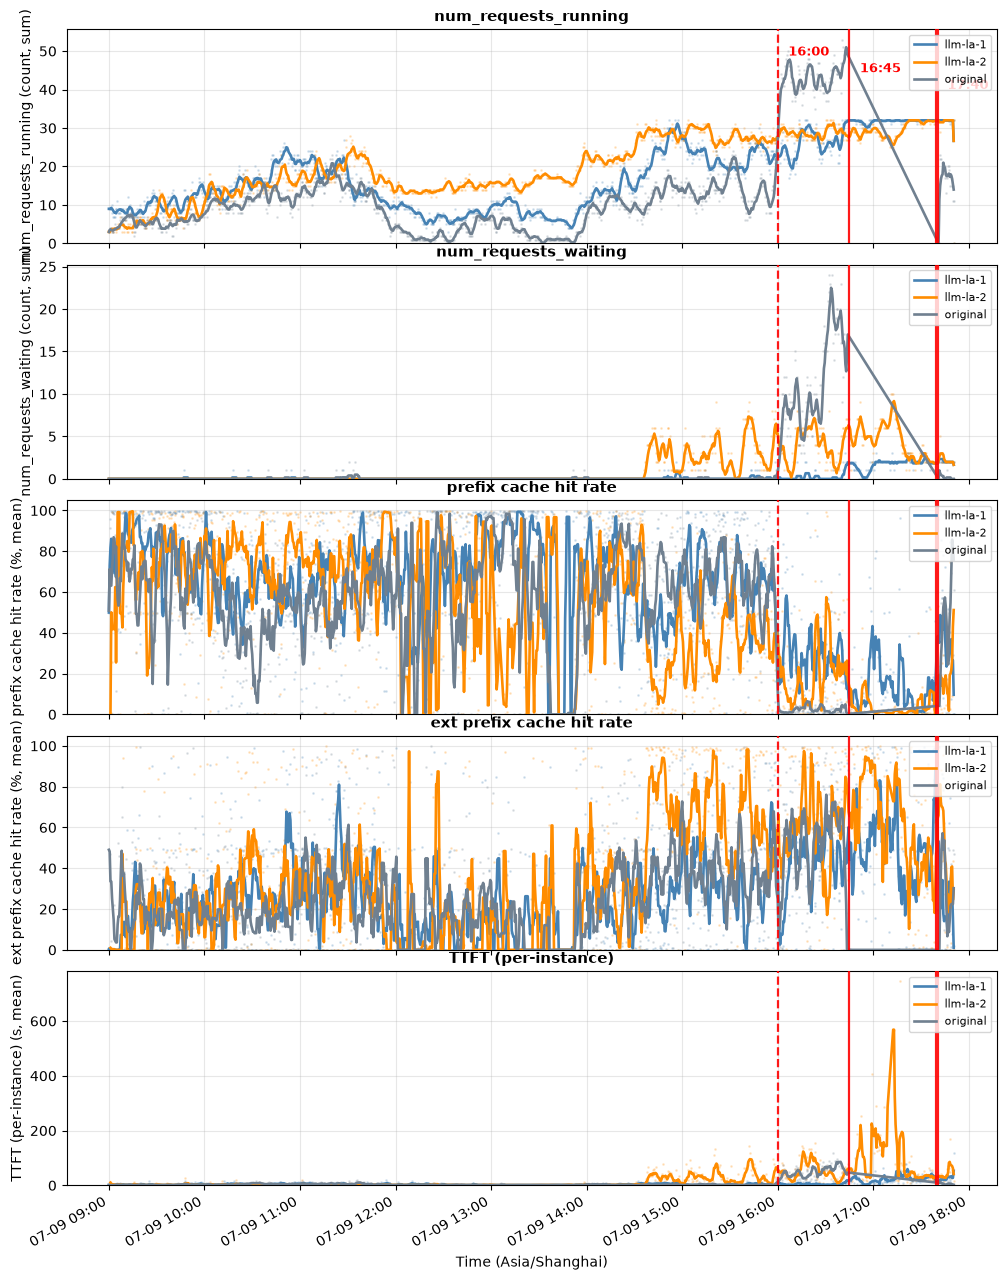

In [106]:
# ============================================================
# 三组实例多指标面板: running / waiting / prefix hit rate / ext hit rate / TTFT
#   llm-la-1 (7.150.6.33) llm-la-2 (7.150.1.218) <- exp83
#   original (7.150.2.142)                        <- exp84
#   分源读取 (142 IP 撞车); prom ts UTC -> Asia/Shanghai; 窗口 Jul-09 09:00 -> now
#   标记线: 虚线@16:00, 实线@17:00, 加粗实线@17:40
# ============================================================
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ---- 指标配置: (列名, 标题, y轴, scale, 聚合方式) ----
METRICS = [
    ("requests_running",          "num_requests_running",      "count", 1.0,   "sum"),
    ("requests_waiting",          "num_requests_waiting",      "count", 1.0,   "sum"),
    ("prefix_cache_hit_rate",     "prefix cache hit rate",     "%",     100.0, "mean"),
    ("ext_prefix_cache_hit_rate", "ext prefix cache hit rate", "%",     100.0, "mean"),
    ("ttft_seconds_avg",          "TTFT (per-instance)",       "s",     1.0,   "mean"),
]

GROUP_SRC = {
    "llm-la-1": (83, {"33"}),
    "llm-la-2": (83, {"218"}),
    "original": (84, {"142"}),
}
COLORS = {"llm-la-1": "steelblue", "llm-la-2": "darkorange", "original": "slategray"}

# ---- 时间窗 (北京墙上时钟) ----
START = "2026-07-09 09:00"
END   = None

# ---- 红色垂直标记线: (时间, 线型, 标签, 线宽, 颜色) ----
MARKS = [
    ("2026-07-09 16:00", "--", "16:00", 1.6, "red"),   # 虚线
    ("2026-07-09 16:45", "-",  "16:45", 1.6, "red"),   # 实线
    ("2026-07-09 17:40", "-",  "17:40", 3.0, "red"),   # 加粗实线
]

PROM_TZ, CACHE_TZ = "UTC", "Asia/Shanghai"
SMOOTH, RESAMPLE, ROLL, SHOW_RAW, SAVE_FIG = True, "30s", "3min", True, True

start = None if START is None else pd.Timestamp(START)
end   = None if END   is None else pd.Timestamp(END)

def _tokens(inst): return set(str(inst).split(":")[0].split(".")) - {""}
def _match(inst, ids): return bool(_tokens(inst) & set(ids))

def _prom_index_to_china(idx):
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def _smooth(s):
    if s.empty: return s
    s = s.sort_index()
    return s.resample(RESAMPLE).mean().rolling(ROLL, min_periods=1).mean().dropna()

# ---- 加载各实验 ----
need_exps = sorted({src for src, _ in GROUP_SRC.values()})
prom_cache = {}
for exp_id in need_exps:
    df = load_experiment_prom_samples(exp_id=exp_id,
                                      experiments_root="/home/data/saeid/experiments")
    prom_cache[exp_id] = df
    if df.empty: print(f"[warn] exp{exp_id}: no prom samples")

# ---- 诊断 ----
for label, (src, ids) in GROUP_SRC.items():
    df = prom_cache.get(src)
    if df is None or df.empty or "instance" not in df.columns:
        print(f"[grp] {label}: (exp{src} no data)"); continue
    hit = sorted(i for i in df["instance"].unique() if _match(i, ids))
    print(f"[grp] {label} (exp{src}, ids={sorted(ids)}): {hit}")

def group_series(metric, scale, agg):
    out = {}
    for label, (src, ids) in GROUP_SRC.items():
        df = prom_cache.get(src)
        if df is None or df.empty or metric not in df.columns or "instance" not in df.columns:
            out[label] = pd.Series(dtype=float); continue
        sub = df[df["instance"].map(lambda s: _match(s, ids))]
        if sub.empty:
            out[label] = pd.Series(dtype=float); continue
        s = sub.groupby("ts")[metric].agg(agg) * scale
        s.index = _prom_index_to_china(s.index)
        s = s.sort_index()
        idx = s.index
        mask = pd.Series(True, index=range(len(idx)))
        if start is not None: mask &= (idx >= start)
        if end   is not None: mask &= (idx <= end)
        out[label] = s[mask.values]
    return out

# ---- 画图 ----
n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.4 * n), sharex=True,
                         gridspec_kw={"hspace": 0.10})
if n == 1: axes = [axes]

data_min = data_max = None
def _observe(idx):
    global data_min, data_max
    if len(idx) == 0: return
    lo, hi = pd.Timestamp(min(idx)), pd.Timestamp(max(idx))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

for ax, (col, title, yunit, scale, agg) in zip(axes, METRICS):
    series = group_series(col, scale, agg)
    any_data = False
    for label, s in series.items():
        if s.empty:
            print(f"[warn] {col} / {label}: 窗口内无数据"); continue
        color = COLORS.get(label)
        if SHOW_RAW:
            ax.plot(s.index, s.values, ".", markersize=2, color=color, alpha=0.18, zorder=1)
        line = _smooth(s) if SMOOTH else s
        if line.empty: continue
        ax.plot(line.index, line.values, linewidth=1.9, color=color, label=label, zorder=3)
        _observe(line.index); any_data = True
        print(f"[ok] {col} / {label}: {s.size} pts, mean={s.mean():.3f}, max={s.max():.3f}")
    ax.set_ylabel(f"{title} ({yunit}, {agg})")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
    if any_data: ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (Asia/Shanghai)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

# ---- 红色垂直标记线 (标注交错排布, 避免重叠) ----
for i, (mt, ls, lbl, lw, mcolor) in enumerate(MARKS):
    if mt is None: continue
    mark = pd.Timestamp(mt)
    for ax in axes:
        ax.axvline(mark, color=mcolor, linestyle=ls, linewidth=lw, alpha=0.9, zorder=5)
    # 标注垂直交错, 防止相邻时间点文字叠一起
    y_off = -12 - (i % 3) * 12
    axes[0].annotate(f" {lbl}", xy=(mark, axes[0].get_ylim()[1]),
                     xytext=(4, y_off), textcoords="offset points",
                     color=mcolor, fontsize=9, fontweight="bold", va="top", ha="left")
    print(f"[mark] {ls!r} lw={lw} at {mark}")

title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max
_fmt = lambda t: pd.Timestamp(t).strftime("%Y-%m-%d %H:%M") if t is not None else "?"
# fig.suptitle(f"running/waiting + prefix/ext hit rate + TTFT  "
#              f"(llm-la-1/2 @exp83, original @exp84)  {_fmt(title_lo)} ~ {_fmt(title_hi)}",
#              fontsize=12, fontweight="bold", y=0.998)
fig.autofmt_xdate(); plt.tight_layout()

if SAVE_FIG:
    os.makedirs("figures", exist_ok=True)
    _stamp = lambda t, fb: pd.Timestamp(t).strftime("%Y%m%d-%H%M") if t is not None else fb
    fname = (f"figures/multi_metrics_running_hitrate_ttft_"
             f"{_stamp(title_lo,'begin')}_{_stamp(title_hi,'end')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight"); print(f"[saved] {fname}")
plt.show()

[grp] llm-la-1 (exp87, ids=['33']): ['7.150.6.33:8200:0', '7.150.6.33:8200:1']
[grp] llm-la-2 (exp87, ids=['218']): ['7.150.1.218:8200:0', '7.150.1.218:8200:1']
[grp] original (exp86, ids=['142']): ['7.150.2.142:8077:0', '7.150.2.142:8077:1']
[ok] requests_running / llm-la-1: 868 pts, mean=24.547, max=48.000
[ok] requests_running / llm-la-2: 868 pts, mean=34.162, max=48.000
[ok] requests_running / original: 858 pts, mean=5.928, max=31.000
[ok] requests_waiting / llm-la-1: 868 pts, mean=0.039, max=2.000
[ok] requests_waiting / llm-la-2: 868 pts, mean=3.535, max=11.000
[ok] requests_waiting / original: 858 pts, mean=0.001, max=1.000
[ok] prefix_cache_hit_rate / llm-la-1: 868 pts, mean=75.651, max=101.887
[ok] prefix_cache_hit_rate / llm-la-2: 868 pts, mean=71.579, max=101.755
[ok] prefix_cache_hit_rate / original: 858 pts, mean=71.164, max=99.950
[ok] ext_prefix_cache_hit_rate / llm-la-1: 868 pts, mean=15.666, max=99.402
[ok] ext_prefix_cache_hit_rate / llm-la-2: 868 pts, mean=11.063, ma

/tmp/ipykernel_2749368/4190851639.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.autofmt_xdate(); plt.tight_layout()


[saved] figures/0710_multi_metrics_running_hitrate_ttft_20260709-1900_20260710-0215.png


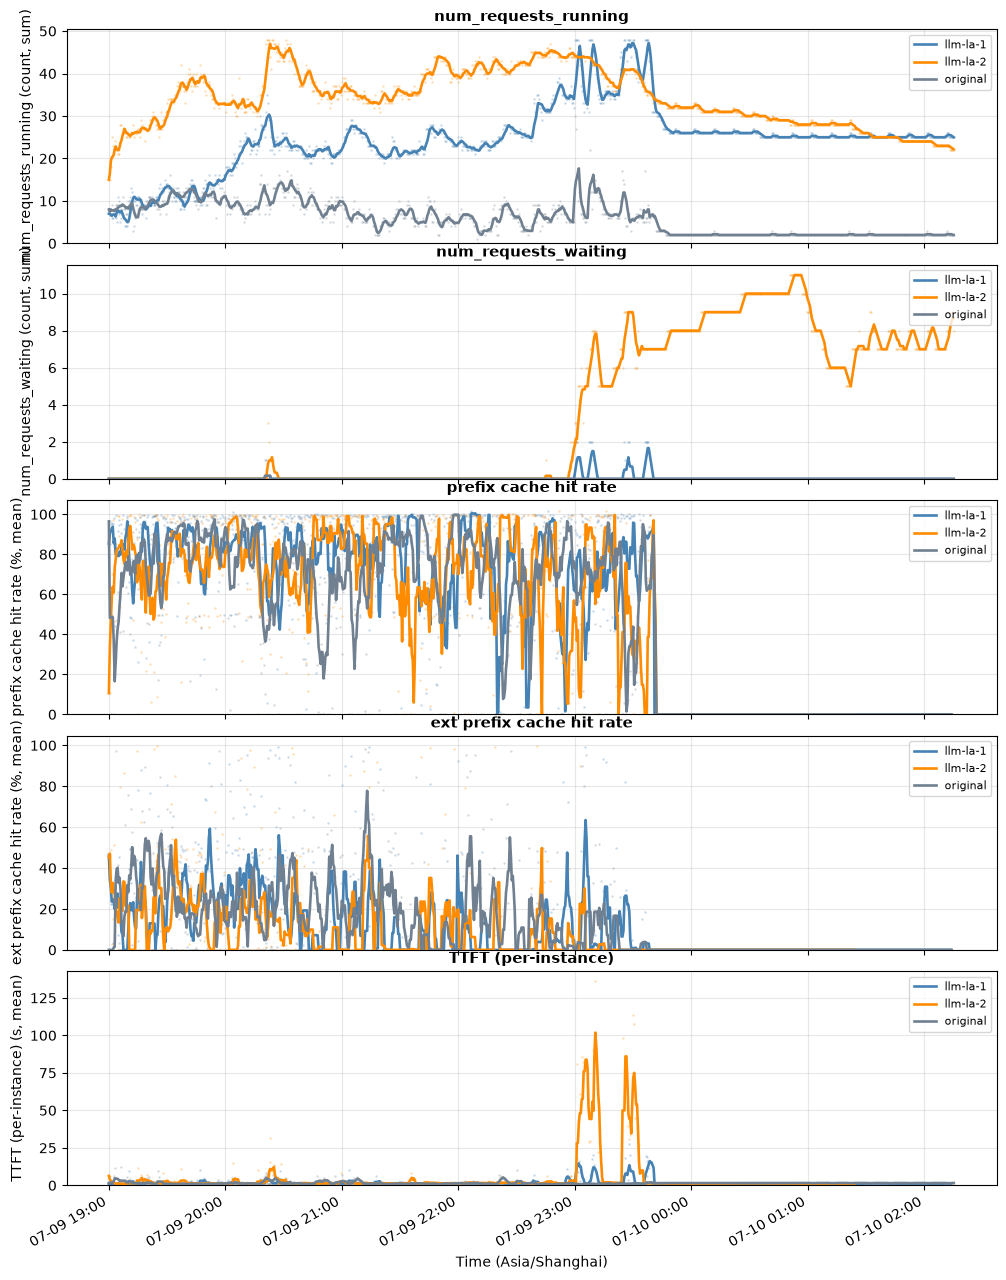

In [123]:
# ============================================================
# 三组实例多指标面板: running / waiting / prefix hit rate / ext hit rate / TTFT
#   llm-la-1 (7.150.6.33) llm-la-2 (7.150.1.218) <- exp83
#   original (7.150.2.142)                        <- exp84
#   分源读取 (142 IP 撞车); prom ts UTC -> Asia/Shanghai; 窗口 Jul-09 09:00 -> now
#   标记线: 虚线@16:00, 实线@17:00, 加粗实线@17:40
# ============================================================
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ---- 指标配置: (列名, 标题, y轴, scale, 聚合方式) ----
METRICS = [
    ("requests_running",          "num_requests_running",      "count", 1.0,   "sum"),
    ("requests_waiting",          "num_requests_waiting",      "count", 1.0,   "sum"),
    ("prefix_cache_hit_rate",     "prefix cache hit rate",     "%",     100.0, "mean"),
    ("ext_prefix_cache_hit_rate", "ext prefix cache hit rate", "%",     100.0, "mean"),
    ("ttft_seconds_avg",          "TTFT (per-instance)",       "s",     1.0,   "mean"),
]

GROUP_SRC = {
    "llm-la-1": (87, {"33"}),
    "llm-la-2": (87, {"218"}),
    "original": (86, {"142"}),
}
COLORS = {"llm-la-1": "steelblue", "llm-la-2": "darkorange", "original": "slategray"}

# ---- 时间窗 (北京墙上时钟) ----
START = "2026-07-09 19:00"
END   = None

# ---- 红色垂直标记线: (时间, 线型, 标签, 线宽, 颜色) ----
MARKS = [
    ("2026-07-09 16:00", "--", "16:00", 1.6, "red"),   # 虚线
    ("2026-07-09 16:45", "-",  "16:45", 1.6, "red"),   # 实线
    ("2026-07-09 17:40", "-",  "17:40", 3.0, "red"),   # 加粗实线
]

PROM_TZ, CACHE_TZ = "UTC", "Asia/Shanghai"
SMOOTH, RESAMPLE, ROLL, SHOW_RAW, SAVE_FIG = True, "30s", "3min", True, True

start = None if START is None else pd.Timestamp(START)
end   = None if END   is None else pd.Timestamp(END)

def _tokens(inst): return set(str(inst).split(":")[0].split(".")) - {""}
def _match(inst, ids): return bool(_tokens(inst) & set(ids))

def _prom_index_to_china(idx):
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def _smooth(s):
    if s.empty: return s
    s = s.sort_index()
    return s.resample(RESAMPLE).mean().rolling(ROLL, min_periods=1).mean().dropna()

# ---- 加载各实验 ----
need_exps = sorted({src for src, _ in GROUP_SRC.values()})
prom_cache = {}
for exp_id in need_exps:
    df = load_experiment_prom_samples(exp_id=exp_id,
                                      experiments_root="/home/data/saeid/experiments")
    prom_cache[exp_id] = df
    if df.empty: print(f"[warn] exp{exp_id}: no prom samples")

# ---- 诊断 ----
for label, (src, ids) in GROUP_SRC.items():
    df = prom_cache.get(src)
    if df is None or df.empty or "instance" not in df.columns:
        print(f"[grp] {label}: (exp{src} no data)"); continue
    hit = sorted(i for i in df["instance"].unique() if _match(i, ids))
    print(f"[grp] {label} (exp{src}, ids={sorted(ids)}): {hit}")

def group_series(metric, scale, agg):
    out = {}
    for label, (src, ids) in GROUP_SRC.items():
        df = prom_cache.get(src)
        if df is None or df.empty or metric not in df.columns or "instance" not in df.columns:
            out[label] = pd.Series(dtype=float); continue
        sub = df[df["instance"].map(lambda s: _match(s, ids))]
        if sub.empty:
            out[label] = pd.Series(dtype=float); continue
        s = sub.groupby("ts")[metric].agg(agg) * scale
        s.index = _prom_index_to_china(s.index)
        s = s.sort_index()
        idx = s.index
        mask = pd.Series(True, index=range(len(idx)))
        if start is not None: mask &= (idx >= start)
        if end   is not None: mask &= (idx <= end)
        out[label] = s[mask.values]
    return out

# ---- 画图 ----
n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.4 * n), sharex=True,
                         gridspec_kw={"hspace": 0.10})
if n == 1: axes = [axes]

data_min = data_max = None
def _observe(idx):
    global data_min, data_max
    if len(idx) == 0: return
    lo, hi = pd.Timestamp(min(idx)), pd.Timestamp(max(idx))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

for ax, (col, title, yunit, scale, agg) in zip(axes, METRICS):
    series = group_series(col, scale, agg)
    any_data = False
    for label, s in series.items():
        if s.empty:
            print(f"[warn] {col} / {label}: 窗口内无数据"); continue
        color = COLORS.get(label)
        if SHOW_RAW:
            ax.plot(s.index, s.values, ".", markersize=2, color=color, alpha=0.18, zorder=1)
        line = _smooth(s) if SMOOTH else s
        if line.empty: continue
        ax.plot(line.index, line.values, linewidth=1.9, color=color, label=label, zorder=3)
        _observe(line.index); any_data = True
        print(f"[ok] {col} / {label}: {s.size} pts, mean={s.mean():.3f}, max={s.max():.3f}")
    ax.set_ylabel(f"{title} ({yunit}, {agg})")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
    if any_data: ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (Asia/Shanghai)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))



title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max
_fmt = lambda t: pd.Timestamp(t).strftime("%Y-%m-%d %H:%M") if t is not None else "?"
# fig.suptitle(f"running/waiting + prefix/ext hit rate + TTFT  "
#              f"(llm-la-1/2 @exp83, original @exp84)  {_fmt(title_lo)} ~ {_fmt(title_hi)}",
#              fontsize=12, fontweight="bold", y=0.998)
fig.autofmt_xdate(); plt.tight_layout()

if SAVE_FIG:
    os.makedirs("figures", exist_ok=True)
    _stamp = lambda t, fb: pd.Timestamp(t).strftime("%Y%m%d-%H%M") if t is not None else fb
    fname = (f"figures/0710_multi_metrics_running_hitrate_ttft_"
             f"{_stamp(title_lo,'begin')}_{_stamp(title_hi,'end')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight"); print(f"[saved] {fname}")
plt.show()

[grp] llm-la-1 (exp87, ids=['33']): ['7.150.6.33:8200:0', '7.150.6.33:8200:1']
[grp] llm-la-2 (exp87, ids=['218']): ['7.150.1.218:8200:0', '7.150.1.218:8200:1']
[grp] original (exp86, ids=['142']): ['7.150.2.142:8077:0', '7.150.2.142:8077:1']
[ok] requests_running / llm-la-1: 865 pts, mean=24.546, max=48.000
[ok] requests_running / llm-la-2: 865 pts, mean=34.205, max=48.000
[ok] requests_running / original: 856 pts, mean=5.937, max=31.000
[ok] requests_waiting / llm-la-1: 865 pts, mean=0.039, max=2.000
[ok] requests_waiting / llm-la-2: 865 pts, mean=3.517, max=11.000
[ok] requests_waiting / original: 856 pts, mean=0.001, max=1.000
[ok] prefix_cache_hit_rate / llm-la-1 (snapshot): 44 pts, mean=89.747, max=90.800
[ok] prefix_cache_hit_rate / llm-la-2 (snapshot): 44 pts, mean=84.980, max=87.250
[ok] prefix_cache_hit_rate / original (snapshot): 44 pts, mean=79.901, max=82.090
[ok] ext_prefix_cache_hit_rate / llm-la-1 (snapshot): 44 pts, mean=45.001, max=46.980
[ok] ext_prefix_cache_hit_rat

/tmp/ipykernel_2749368/552568496.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.autofmt_xdate(); plt.tight_layout()


[saved] figures/0710_multi_metrics_snaphr_20260709-1900_20260710-0214.png


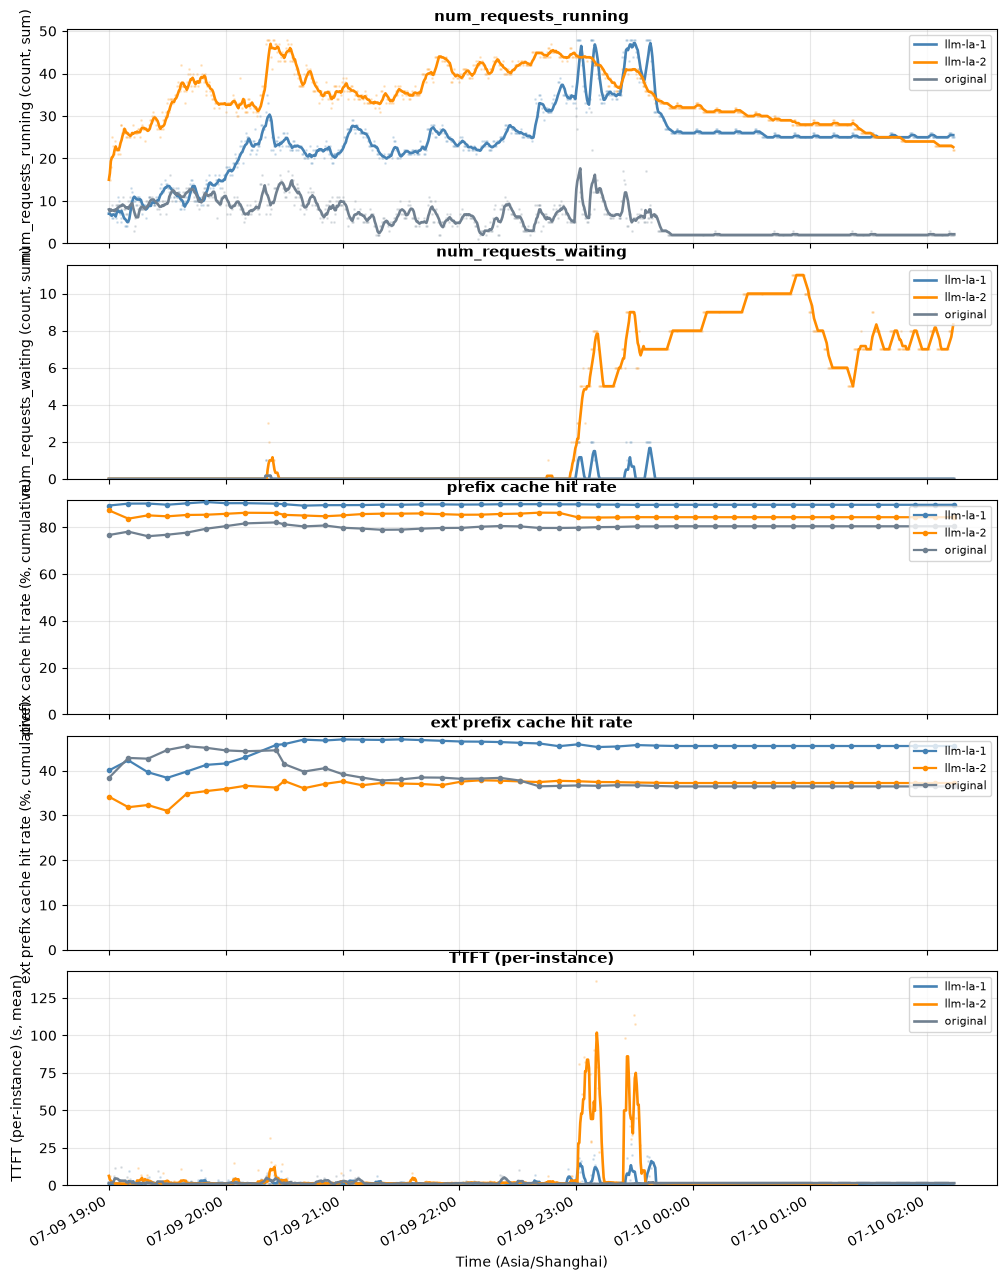

In [122]:
# ============================================================
# 三组实例多指标面板: running / waiting / prefix hit rate / ext hit rate / TTFT
#   running/waiting/TTFT <- prom (exp87 / exp86, gauge, 即时)
#   两条 hit rate        <- snapshot (identifier, 累计 %, China wall-clock)
#     llm-la-1 <- MiniMax-M2.7-llmla1-direct65  (IP .33)
#     llm-la-2 <- MiniMax-M2.7-llmla2-direct65  (IP .218)
#     original <- MiniMax-M2.7-direct142        (IP .142)
# ============================================================
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ---- 指标配置: (列名, 标题, y轴, scale, 聚合方式) ----
METRICS = [
    ("requests_running",          "num_requests_running",      "count", 1.0,   "sum"),
    ("requests_waiting",          "num_requests_waiting",      "count", 1.0,   "sum"),
    ("prefix_cache_hit_rate",     "prefix cache hit rate",     "%",     1.0,    "mean"),
    ("ext_prefix_cache_hit_rate", "ext prefix cache hit rate", "%",     1.0,    "mean"),
    ("ttft_seconds_avg",          "TTFT (per-instance)",       "s",     1.0,   "mean"),
]

# prom 侧分组 (running/waiting/ttft 用)
GROUP_SRC = {
    "llm-la-1": (87, {"33"}),
    "llm-la-2": (87, {"218"}),
    "original": (86, {"142"}),
}
# snapshot 侧分组 (两条 hit rate 用) —— 已确认映射
SNAP_MAP = {
    "llm-la-1": "MiniMax-M2.7-llmla1-direct65",
    "llm-la-2": "MiniMax-M2.7-llmla2-direct65",
    "original": "MiniMax-M2.7-direct142",
}
SNAP_FIELD = {   # 面板列名 -> snapshot 字段 (累计 %, 已是 0-100)
    "prefix_cache_hit_rate":     "prefix_cache_hits_percent",
    "ext_prefix_cache_hit_rate": "external_prefix_cache_hits_percent",
}
COLORS = {"llm-la-1": "steelblue", "llm-la-2": "darkorange", "original": "slategray"}

# ---- 时间窗 (北京墙上时钟) ----
START = "2026-07-09 19:00"
END   = None

PROM_TZ, CACHE_TZ = "UTC", "Asia/Shanghai"
SMOOTH, RESAMPLE, ROLL, SHOW_RAW, SAVE_FIG = True, "30s", "3min", True, True

start = None if START is None else pd.Timestamp(START)
end   = None if END   is None else pd.Timestamp(END)

def _tokens(inst): return set(str(inst).split(":")[0].split(".")) - {""}
def _match(inst, ids): return bool(_tokens(inst) & set(ids))

def _prom_index_to_china(idx):
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def _smooth(s):
    if s.empty: return s
    s = s.sort_index()
    return s.resample(RESAMPLE).mean().rolling(ROLL, min_periods=1).mean().dropna()

# ---- 加载 prom (running/waiting/ttft) ----
need_exps = sorted({src for src, _ in GROUP_SRC.values()})
prom_cache = {}
for exp_id in need_exps:
    df = load_experiment_prom_samples(exp_id=exp_id,
                                      experiments_root="/home/data/saeid/experiments")
    prom_cache[exp_id] = df
    if df.empty: print(f"[warn] exp{exp_id}: no prom samples")

# ---- 加载 snapshot (hit rate) ----
snaps = list(load_snapshots())

# ---- 诊断: prom 分组 ----
for label, (src, ids) in GROUP_SRC.items():
    df = prom_cache.get(src)
    if df is None or df.empty or "instance" not in df.columns:
        print(f"[grp] {label}: (exp{src} no data)"); continue
    hit = sorted(i for i in df["instance"].unique() if _match(i, ids))
    print(f"[grp] {label} (exp{src}, ids={sorted(ids)}): {hit}")

# ---- prom series (gauge, 即时) ----
def group_series(metric, scale, agg):
    out = {}
    for label, (src, ids) in GROUP_SRC.items():
        df = prom_cache.get(src)
        if df is None or df.empty or metric not in df.columns or "instance" not in df.columns:
            out[label] = pd.Series(dtype=float); continue
        sub = df[df["instance"].map(lambda s: _match(s, ids))]
        if sub.empty:
            out[label] = pd.Series(dtype=float); continue
        s = sub.groupby("ts")[metric].agg(agg) * scale
        s.index = _prom_index_to_china(s.index)
        s = s.sort_index()
        idx = s.index
        mask = pd.Series(True, index=range(len(idx)))
        if start is not None: mask &= (idx >= start)
        if end   is not None: mask &= (idx <= end)
        out[label] = s[mask.values]
    return out

# ---- snapshot series (累计 %, China wall-clock, 不转时区) ----
def _read_snap(identifier, field):
    pts = {}
    for _, d in snaps:
        ts = [parse_ts(x) for x in (d.get("timestamps") or [])]
        v = (d.get("identifier_metrics") or {}).get(identifier)
        if not v: continue
        arr = v.get(field) or []
        for i in range(min(len(arr), len(ts))):
            if ts[i] is not None and arr[i] is not None:
                pts[ts[i]] = arr[i]
    return pd.Series(pts).sort_index()

def snap_series(field):
    out = {}
    for label, ident in SNAP_MAP.items():
        s = _read_snap(ident, field)
        if s.empty:
            out[label] = s; continue
        idx = s.index
        mask = pd.Series(True, index=range(len(idx)))
        if start is not None: mask &= (idx >= start)
        if end   is not None: mask &= (idx <= end)
        out[label] = s[mask.values]
    return out

# ---- 画图 ----
n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.4 * n), sharex=True,
                         gridspec_kw={"hspace": 0.10})
if n == 1: axes = [axes]

data_min = data_max = None
def _observe(idx):
    global data_min, data_max
    if len(idx) == 0: return
    lo, hi = pd.Timestamp(min(idx)), pd.Timestamp(max(idx))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

for ax, (col, title, yunit, scale, agg) in zip(axes, METRICS):
    any_data = False

    if col in SNAP_FIELD:
        # ---- hit rate: snapshot 累计 %, 直接画 (无需 smooth/时区转换) ----
        series = snap_series(SNAP_FIELD[col])
        for label, s in series.items():
            if s.empty:
                print(f"[warn] {col} / {label}: 窗口内无数据"); continue
            s = s.sort_index()
            ax.plot(s.index, s.values, marker="o", markersize=3, linewidth=1.6,
                    color=COLORS.get(label), label=label, zorder=3)
            _observe(s.index); any_data = True
            print(f"[ok] {col} / {label} (snapshot): {s.size} pts, "
                  f"mean={s.mean():.3f}, max={s.max():.3f}")
        ax.set_ylabel(f"{title} ({yunit}, cumulative)")
    else:
        # ---- prom gauge: 原逻辑不动 ----
        series = group_series(col, scale, agg)
        for label, s in series.items():
            if s.empty:
                print(f"[warn] {col} / {label}: 窗口内无数据"); continue
            color = COLORS.get(label)
            if SHOW_RAW:
                ax.plot(s.index, s.values, ".", markersize=2, color=color, alpha=0.18, zorder=1)
            line = _smooth(s) if SMOOTH else s
            if line.empty: continue
            ax.plot(line.index, line.values, linewidth=1.9, color=color, label=label, zorder=3)
            _observe(line.index); any_data = True
            print(f"[ok] {col} / {label}: {s.size} pts, mean={s.mean():.3f}, max={s.max():.3f}")
        ax.set_ylabel(f"{title} ({yunit}, {agg})")

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
    if any_data: ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (Asia/Shanghai)")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max
_fmt = lambda t: pd.Timestamp(t).strftime("%Y-%m-%d %H:%M") if t is not None else "?"
fig.autofmt_xdate(); plt.tight_layout()

if SAVE_FIG:
    os.makedirs("figures", exist_ok=True)
    _stamp = lambda t, fb: pd.Timestamp(t).strftime("%Y%m%d-%H%M") if t is not None else fb
    fname = (f"figures/0710_multi_metrics_snaphr_"
             f"{_stamp(title_lo,'begin')}_{_stamp(title_hi,'end')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight"); print(f"[saved] {fname}")
plt.show()

[grp] llm-la-1 (exp79, ids=['33', '37']): ['7.150.6.33:8200:0', '7.150.6.33:8200:1']
[grp] llm-la-2 (exp79, ids=['207', '218']): ['7.150.1.218:8200:0', '7.150.1.218:8200:1']
[grp] original (exp78, ids=['142', '50']): ['7.150.2.142:8077:0', '7.150.2.142:8077:1']
[mark] vertical line at 2026-07-08 14:30:00


/tmp/ipykernel_2749368/1418668712.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.autofmt_xdate(); plt.tight_layout()


[saved] figures/prefix_ext_e2e_20260708-0900_20260708-1812.png


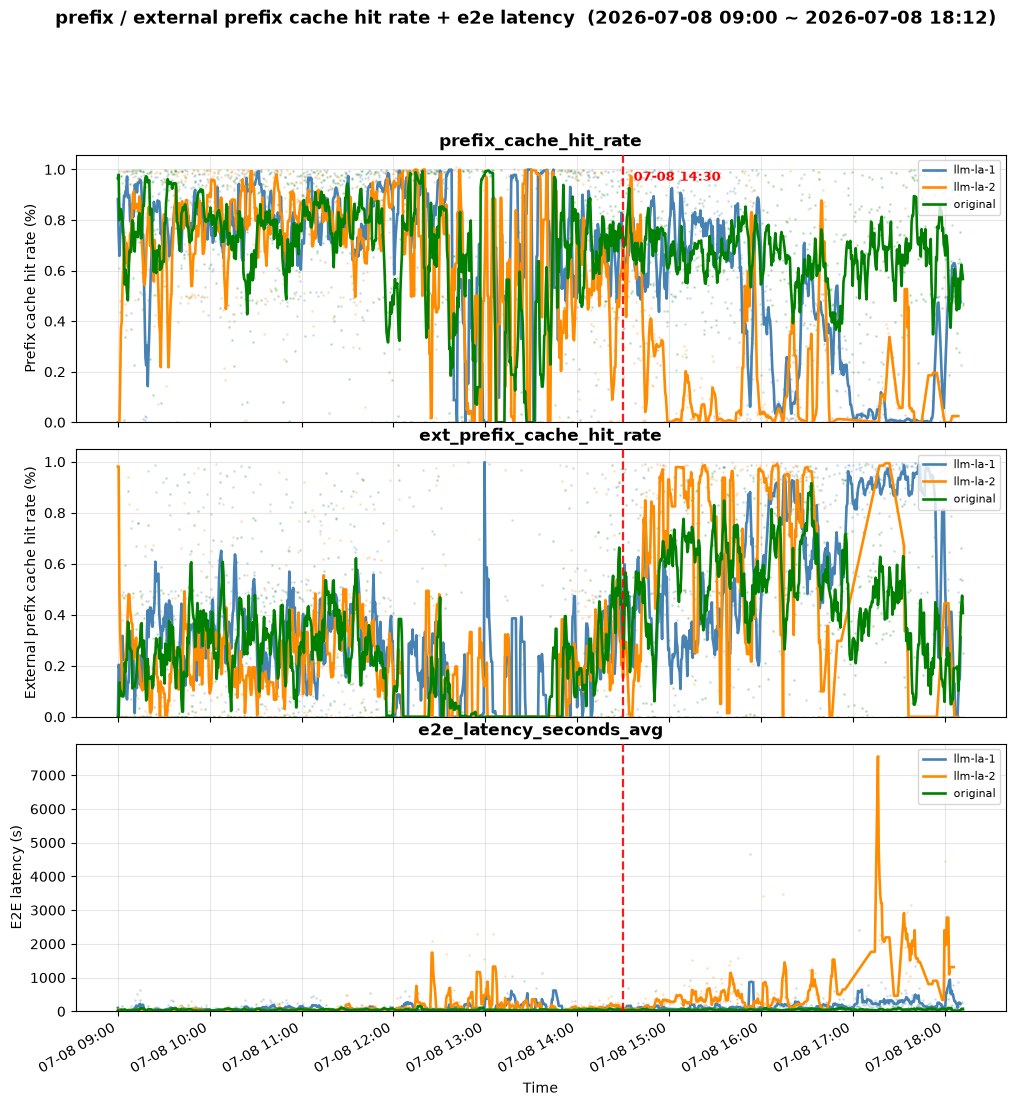

In [62]:
# ============================================================
# Prom 多指标分组面板 (平滑版):
#   prefix_cache_hit_rate / ext_prefix_cache_hit_rate / e2e_latency_seconds_avg
#   exp 79 -> llm-la-1 (33,37) + llm-la-2 (218,207)
#   exp 78 -> original  (142,50)
#   prom ts = UTC -> Asia/Shanghai 墙上时钟
# ============================================================
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import re, os

# ---- 要画的指标 (每个一个 panel) ----
# (列名, y 轴标签, scale)  如果指标是 0-1 的 fraction 就把 scale 设成 100
METRICS = [
    ("prefix_cache_hit_rate",     "Prefix cache hit rate (%)",          1.0),
    ("ext_prefix_cache_hit_rate", "External prefix cache hit rate (%)", 1.0),
    ("e2e_latency_seconds_avg",   "E2E latency (s)",                    1.0),
]

# ---- 实例分组: label -> 出现在 prom `instance` 字符串里的数字 token 集合 ----
GROUPS = {
    "llm-la-1": {"33", "37"},
    "llm-la-2": {"218", "207"},
    "original": {"142", "50"},
}
GROUP_EXP = {"llm-la-1": 79, "llm-la-2": 79, "original": 78}

INSTANCE_COL = "instance"   # prom df 里真正的实例列名 (IP:port:dp_rank)
AGG = "mean"                # 组内跨实例聚合方式 (hit rate / avg latency 用 mean)

# ---- 时间窗 (北京墙上时钟) ----
START = "2026-07-08 09:00"
END   = None
MARK_TIME = "2026-07-08 14:30"   # 或 "auto" (取第一个指标 llm-la-1 的峰值)

# ---- 平滑配置 ----
SMOOTH   = True
RESAMPLE = "30s"     # 先重采样到固定节奏 (按采样间隔调, 采样稀就调大)
ROLL     = "3min"    # 再做时间窗滚动均值 (调大=更平滑; 命中率毛刺重可试 5min)
SHOW_RAW = True      # 背景叠一层淡原始点, 保留真实分布

PROM_TZ, CACHE_TZ = "UTC", "Asia/Shanghai"
COLORS = {"llm-la-1": "steelblue", "llm-la-2": "darkorange", "original": "green"}

start, end = parse_window(START), parse_window(END)

def _prom_index_to_china(idx):
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def _tokens(inst):
    return set(re.split(r"[^0-9]+", str(inst))) - {""}   # 精确数字段匹配, "33" 不命中 "133"

def _match(inst, ids):
    return bool(_tokens(inst) & set(ids))

def _smooth(s):
    if s.empty: return s
    s = s.sort_index()
    return s.resample(RESAMPLE).mean().rolling(ROLL, min_periods=1).mean().dropna()

# ---- 每个实验的 prom 只加载一次 ----
prom_cache = {}
for exp_id in set(GROUP_EXP.values()):
    df = load_experiment_prom_samples(exp_id=exp_id,
                                      experiments_root="/home/data/saeid/experiments")
    prom_cache[exp_id] = df
    if df.empty:
        print(f"[warn] exp{exp_id}: no prom samples")
    elif INSTANCE_COL not in df.columns:
        print(f"[warn] exp{exp_id}: 没有 '{INSTANCE_COL}' 列, columns = {list(df.columns)}")

# ---- 诊断: 每个组实际命中了哪些 instance ----
for label, ids in GROUPS.items():
    df = prom_cache.get(GROUP_EXP[label])
    if df is None or df.empty or INSTANCE_COL not in df.columns:
        print(f"[grp] {label}: (no data)"); continue
    matched = sorted({v for v in df[INSTANCE_COL].unique() if _match(v, ids)})
    print(f"[grp] {label} (exp{GROUP_EXP[label]}, ids={sorted(ids)}): {matched}")

# ---- 记录实际画出来的时间跨度 ----
data_min = data_max = None
def _observe(idx):
    global data_min, data_max
    if len(idx) == 0: return
    lo, hi = pd.Timestamp(min(idx)), pd.Timestamp(max(idx))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

def group_series(metric, scale):
    """{label: series(北京墙上时钟)}  组内跨实例 mean, 裁剪到窗口."""
    out = {}
    for label, ids in GROUPS.items():
        df = prom_cache.get(GROUP_EXP[label])
        if df is None or df.empty or metric not in df.columns or INSTANCE_COL not in df.columns:
            out[label] = pd.Series(dtype=float); continue
        sub = df[df[INSTANCE_COL].map(lambda s: _match(s, ids))]
        if sub.empty:
            out[label] = pd.Series(dtype=float); continue
        s = sub.groupby("ts")[metric].agg(AGG) * scale
        s.index = _prom_index_to_china(s.index)
        s = s.sort_index()
        idx = s.index
        mask = pd.Series(True, index=idx)
        if start is not None: mask &= idx >= start
        if end   is not None: mask &= idx <= end
        out[label] = s[mask.values]
    return out

# ---- 画图 ----
n = len(METRICS)
fig, axes = plt.subplots(n, 1, figsize=(12, 4.2 * n), sharex=True,
                         gridspec_kw={"hspace": 0.10})
if n == 1: axes = [axes]

peak_time = None
for ax, (col, ylabel, scale) in zip(axes, METRICS):
    series = group_series(col, scale)
    any_data = False
    for label, s in series.items():
        if s.empty:
            print(f"[warn] {col} / {label}: 窗口内无数据"); continue
        color = COLORS.get(label)
        if SHOW_RAW:                                   # 背景: 淡原始点
            ax.plot(s.index, s.values, ".", markersize=2,
                    color=color, alpha=0.18, zorder=1)
        line = _smooth(s) if SMOOTH else s             # 前景: 平滑趋势线
        if line.empty: continue
        ax.plot(line.index, line.values, linewidth=1.9,
                color=color, label=label, zorder=3)
        _observe(line.index); any_data = True
        if peak_time is None and label == "llm-la-1":
            peak_time = line.idxmax()
    ax.set_ylabel(ylabel)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
    if any_data: ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time")

# ---- 红色参考线 ----
mark = peak_time if MARK_TIME == "auto" else pd.Timestamp(MARK_TIME)
if mark is not None:
    for ax in axes:
        ax.axvline(mark, color="red", linestyle="--", linewidth=1.6, alpha=0.9, zorder=5)
    axes[0].annotate(f" {mark:%m-%d %H:%M}", xy=(mark, axes[0].get_ylim()[1]),
                     xytext=(4, -12), textcoords="offset points",
                     color="red", fontsize=9, fontweight="bold", va="top", ha="left")
    print(f"[mark] vertical line at {mark}")

# ---- 标题 + x 轴格式 ----
title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max
_fmt = lambda ts: pd.Timestamp(ts).strftime("%Y-%m-%d %H:%M") if ts is not None else "?"
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle(f"prefix / external prefix cache hit rate + e2e latency  "
             f"({_fmt(title_lo)} ~ {_fmt(title_hi)})",
             fontsize=13, fontweight="bold", y=0.995)
fig.autofmt_xdate(); plt.tight_layout()

# ---- 保存 ----
os.makedirs("figures", exist_ok=True)
_stamp = lambda ts, fb: pd.Timestamp(ts).strftime("%Y%m%d-%H%M") if ts is not None else fb
fname = (f"figures/prefix_ext_e2e_"
         f"{_stamp(title_lo,'begin')}_{_stamp(title_hi,'end')}.png")
fig.savefig(fname, dpi=150, bbox_inches="tight")
print(f"[saved] {fname}")
plt.show()

[ok] exp 79: 1098 个样本 (窗口内), mean=0.228, max=0.931 req/s
[saved] figures/router_admission_rps_exp79_20260708-0900_end.png


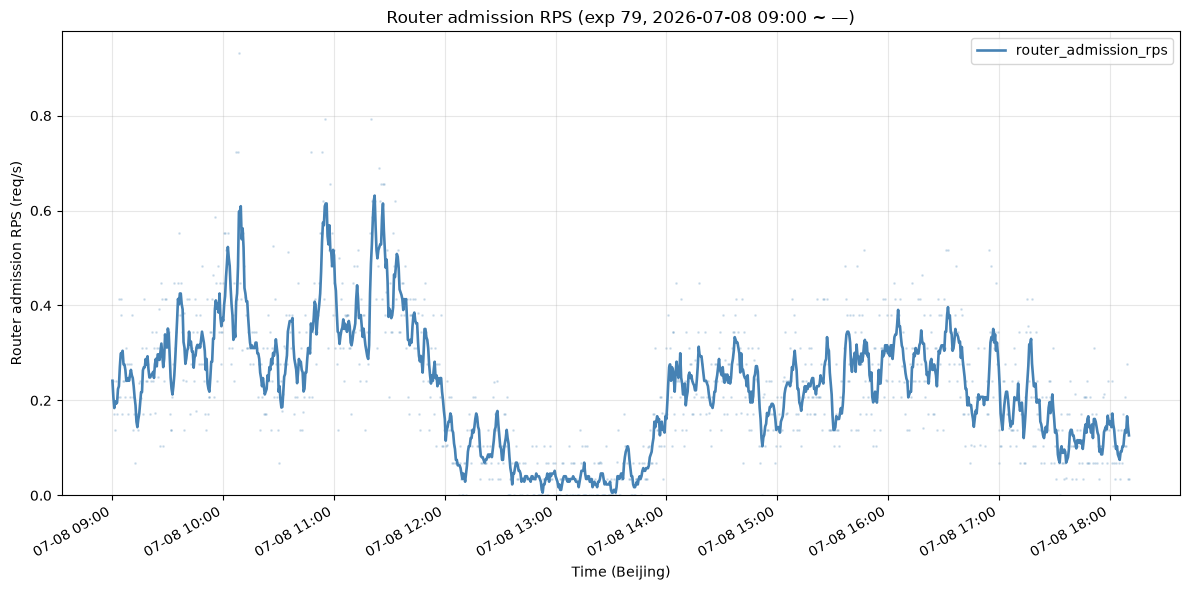

In [84]:
# ============================================================
# Router admission RPS (全局标量, 单条线) from metrics.jsonl
#
# Source = /home/data/saeid/experiments/<exp>/metrics.jsonl
#   router_admission_rps 是 router 入口的全局准入速率, 对所有 instance 恒等,
#   所以每个 ts 取其唯一值即可, 不分实例。
#   ts = ISO8601 (UTC) -> Asia/Shanghai 墙上时钟
# ============================================================
from pathlib import Path
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

EXPERIMENTS_ROOT = "/home/data/saeid/experiments"
EXP_ID   = 79
METRIC   = "router_admission_rps"
PROM_TZ, CACHE_TZ = "UTC", "Asia/Shanghai"

# ---- 时间窗 (北京墙上时钟, 与 prom cell 一致); None = 不设该边界 ----
START = "2026-07-08 09:00"
END   = None

# ---- 平滑 (与 prom cell 同款) ----
SMOOTH   = True
RESAMPLE = "30s"       # collector 采样节奏 (~30s)
ROLL     = "3min"      # 时间窗滚动均值
SHOW_RAW = True        # 背景叠淡原始采样点
COLOR    = "steelblue"
SAVE_FIG = True

start = None if START is None else pd.Timestamp(START)
end   = None if END   is None else pd.Timestamp(END)

def _ts_to_china(idx):
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def _smooth(s):
    if s.empty: return s
    s = s.sort_index()
    return s.resample(RESAMPLE).mean().rolling(ROLL, min_periods=1).mean().dropna()

# ---- 读 metrics.jsonl: 每个 ts 取 admission 的唯一值 (全局标量) ----
path = Path(EXPERIMENTS_ROOT) / str(EXP_ID) / "metrics.jsonl"
if not path.is_file():
    raise FileNotFoundError(path)

ts_list, val_list = [], []
with path.open(encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        rec = json.loads(line)
        ts = rec.get("ts")
        # 全局标量: 取该 ts 下任一有值的 sample 即可 (用 mean 兜底数值噪声)
        vals = [s.get(METRIC) for s in rec.get("samples", [])
                if isinstance(s.get(METRIC), (int, float))]
        if ts is not None and vals:
            ts_list.append(ts)
            val_list.append(float(np.mean(vals)))

s = pd.Series(val_list, index=pd.to_datetime(ts_list, utc=True)).sort_index()
if s.empty:
    print(f"[warn] exp {EXP_ID}: metrics.jsonl 里没有 {METRIC} 样本")
else:
    s.index = _ts_to_china(s.index)               # -> 北京墙上时钟
    mask = pd.Series(True, index=range(len(s.index)))
    if start is not None: mask &= (s.index >= start)
    if end   is not None: mask &= (s.index <= end)
    s = s[mask.values]
    print(f"[ok] exp {EXP_ID}: {s.size} 个样本 (窗口内), "
          f"mean={s.mean():.3f}, max={s.max():.3f} req/s")

# ---- 画图 ----
fig, ax = plt.subplots(figsize=(12, 6))
if not s.empty:
    if SHOW_RAW:
        ax.plot(s.index, s.values, ".", markersize=2, color=COLOR, alpha=0.18, zorder=1)
    line = _smooth(s) if SMOOTH else s
    if not line.empty:
        ax.plot(line.index, line.values, linewidth=1.9, color=COLOR,
                label="router_admission_rps", zorder=3)
        ax.legend(loc="upper right")

ax.set_xlabel("Time (Beijing)")
ax.set_ylabel("Router admission RPS (req/s)")
_fmt = lambda t: t if t is not None else "—"
ax.set_title(f"Router admission RPS (exp {EXP_ID}, {_fmt(START)} ~ {_fmt(END)})")
ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate(); plt.tight_layout()

if SAVE_FIG:
    os.makedirs("figures", exist_ok=True)
    _stamp = lambda t, fb: pd.Timestamp(t).strftime("%Y%m%d-%H%M") if t else fb
    fname = f"figures/router_admission_rps_exp{EXP_ID}_{_stamp(START,'begin')}_{_stamp(END,'end')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); print(f"[saved] {fname}")
plt.show()

[ok] top exp79 -> llm-la-all: 1045 points, mean=60.04
[peak] exp79 (llm-la-all): requests_running max = 122 at 2026-07-08 16:16:15.081947
[ok] top exp78 -> original: 1033 points, mean=10.72
[ok] derived original (2 times projected): 1033 points, mean=21.44
[ok] cache MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 53 points
[ok] cache MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 53 points
[ok] cache MiniMax-M2.7-direct142 -> original: 53 points
[ok] ttft MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 53 points
[ok] ttft MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 46 points
[ok] ttft MiniMax-M2.7-direct142 -> original: 53 points
[mark] vertical line at 2026-07-08 14:20:00


/tmp/ipykernel_2749368/795944854.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[saved] figures/requests_running_prefix_cache_ttft_20260708-0900_20260708-1744.png


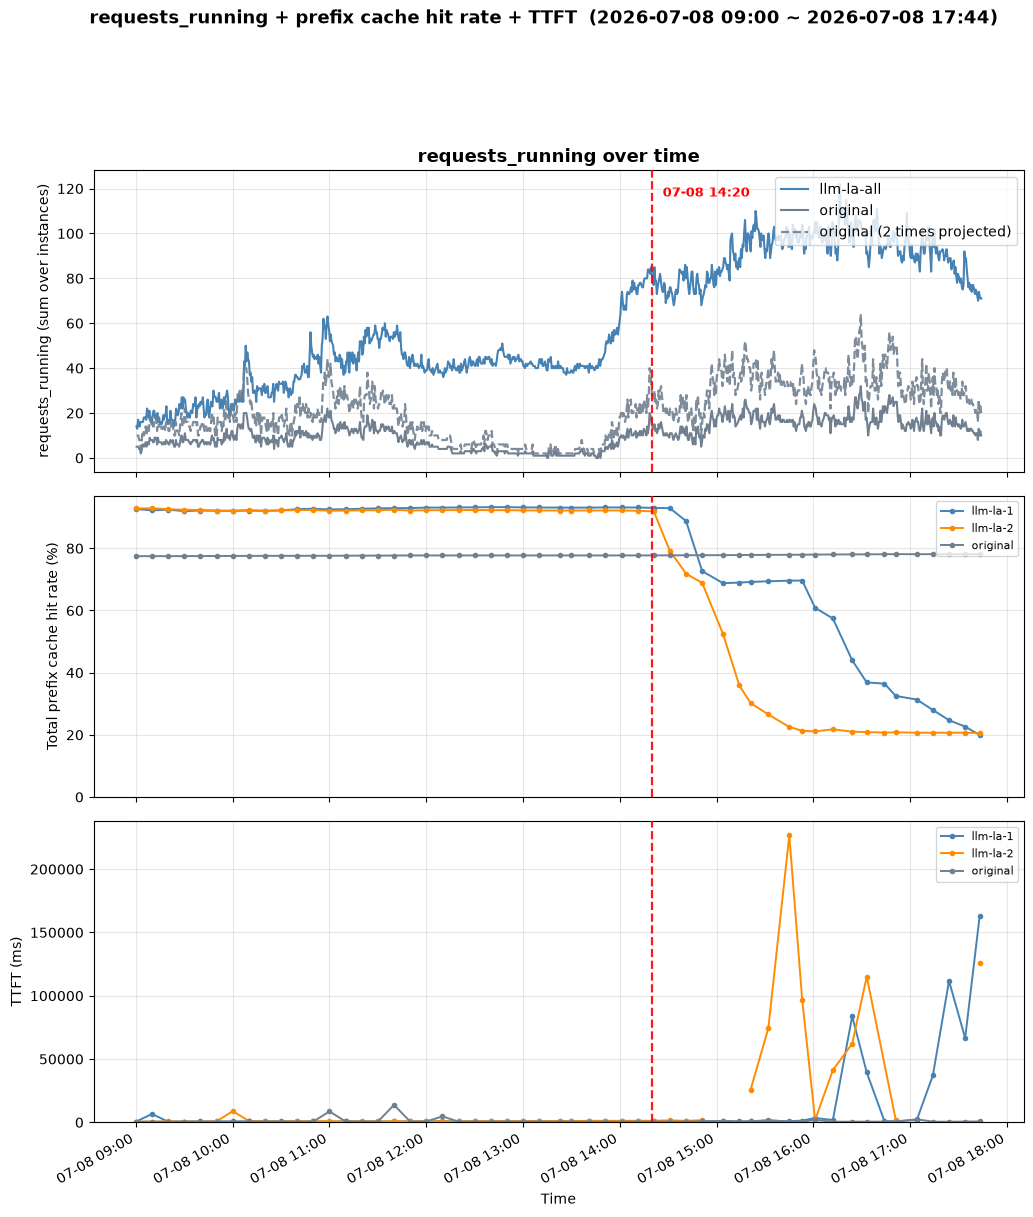

In [57]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ============================================================
# Combined: prom metric (top) + prefix cache hit rate (mid) + TTFT (bottom)
#   prom timestamps  = UTC  -> converted to China
#   cache / ttft ts  = China wall-clock (Asia/Shanghai)
# ============================================================

# ---- top panel config (prom metric) ----
# exp_id -> display label. exp79 = llm-la-all, exp78 = original (baseline)
EXP_LABELS = {
    79: "llm-la-all",
    78: "original",
}
PEAK_EXP = 79            # which experiment defines the red-marker peak
metric = "requests_running"

agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

# ---- derived reference line on the top panel ----
# 画一条 baseline 的线性外推线：数值 = original 每点 × factor
DERIVED = {
    "from":   "original",                  # 源曲线的 display label
    "label":  "original (2 times projected)",
    "factor": 2.0,
}

# ---- shared window (China wall-clock) ----
START  = "2026-07-08 09:00"
END    = None
LABELS = ["llm-la-1", "llm-la-2", "original"]

# ---- timezone config ----
PROM_TZ  = "UTC"
CACHE_TZ = "Asia/Shanghai"

# ---- vertical marker config ----
# "auto"  -> place line at the requests_running peak (argmax of PEAK_EXP series)
# or set an explicit China wall-clock string, e.g. "2026-07-08 14:30"
MARK_TIME = "2026-07-08 14:20"

# ---- shared color convention ----
COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
    "llm-la-all": "steelblue",
    "original": "slategray",
    "boom gateway": "slategray",
}

start, end = parse_window(START), parse_window(END)   # naive China wall-clock

def _prom_index_to_china(idx):
    """Prom index is UTC (aware or naive) -> naive China wall-clock to match cache."""
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

def build_ttft(models):
    """Return {model: {datetime: ttft_ms}} taken directly from the ttft field."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            ttft = v.get("ttft") or []
            n = min(len(ttft), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or ttft[i] is None: continue
                series[m][ts_dt[i]] = round(ttft[i], 2)
    return series

# track the real extent of everything plotted (China wall-clock)
data_min = None
data_max = None
def _observe(ts_index):
    global data_min, data_max
    if len(ts_index) == 0:
        return
    lo, hi = pd.Timestamp(min(ts_index)), pd.Timestamp(max(ts_index))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

fig, (ax_top, ax_bot, ax_ttft) = plt.subplots(
    3, 1, figsize=(12, 14), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.08})

# ---------------- TOP: prom metric (multiple experiments) ----------------
if agg_mode == "sum":
    y_label_top = f"{metric} (sum over instances)"
else:
    y_label_top = f"{metric} (mean over instances)"

peak_time = None   # China wall-clock timestamp of the PEAK_EXP series max
top_series = {}    # disp -> series, 供派生线取用

for exp_id, disp in EXP_LABELS.items():
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
    else:
        series = prom.groupby("ts")[metric].mean()

    # UTC -> China wall-clock, then clip to the same window as the other panels
    series.index = _prom_index_to_china(series.index)
    idx = series.index
    mask = pd.Series(True, index=idx)
    if start is not None:
        mask &= idx >= start
    if end is not None:
        mask &= idx <= end
    series = series[mask.values]
    if series.empty:
        print(f"[warn] exp{exp_id} ({disp}): no {metric} points in window"); continue

    ax_top.plot(series.index, series.values, label=disp, color=COLORS.get(disp))
    _observe(series.index)
    top_series[disp] = series          # 缓存，供派生线用
    print(f"[ok] top exp{exp_id} -> {disp}: {len(series)} points, mean={series.mean():.2f}")

    # red marker peak comes from the designated experiment only
    if exp_id == PEAK_EXP:
        peak_time = series.idxmax()
        print(f"[peak] exp{exp_id} ({disp}): {metric} max = {series.max():.3g} at {peak_time}")

# ---- derived: original × factor (same color, dashed) ----
src = top_series.get(DERIVED["from"])
if src is not None and not src.empty:
    scaled = src * DERIVED["factor"]
    ax_top.plot(scaled.index, scaled.values,
                color=COLORS.get(DERIVED["from"]),   # 和 original 同色
                linestyle="--", linewidth=1.6, alpha=0.9,
                label=DERIVED["label"])
    _observe(scaled.index)
    print(f"[ok] derived {DERIVED['label']}: {len(scaled)} points, mean={scaled.mean():.2f}")
else:
    print(f"[warn] derived line skipped: source '{DERIVED['from']}' not plotted")

ax_top.set_ylabel(y_label_top)
ax_top.set_title(f"{metric} over time", fontsize=13, fontweight="bold")
ax_top.legend(loc="upper right")
ax_top.grid(True, alpha=0.3)

# ---------------- MIDDLE: prefix cache hit rate ----------------
cache = filter_window(build_cache(MODELS), start, end)
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] cache {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_bot.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                            color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] cache {m} -> {disp}: {len(pts)} points")

ax_bot.set_ylabel("Total prefix cache hit rate (%)")
ax_bot.legend(fontsize=8, loc="upper right")
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(bottom=0)

# ---------------- BOTTOM: TTFT (script test result) ----------------
ttft = filter_window(build_ttft(MODELS), start, end)
for i, (m, pts) in enumerate(ttft.items()):
    if not pts:
        print(f"[warn] ttft {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_ttft.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                             color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] ttft {m} -> {disp}: {len(pts)} points")

ax_ttft.set_ylabel("TTFT (ms)")
ax_ttft.set_xlabel("Time")
ax_ttft.legend(fontsize=8, loc="upper right")
ax_ttft.grid(True, alpha=0.3)
ax_ttft.set_ylim(bottom=0)

# ---------------- vertical red marker ----------------
if MARK_TIME == "auto":
    mark = peak_time
else:
    mark = pd.Timestamp(MARK_TIME)   # explicit China wall-clock

if mark is not None:
    for ax in (ax_top, ax_bot, ax_ttft):
        ax.axvline(mark, color="red", linestyle="--", linewidth=1.6, alpha=0.9, zorder=5)
    ax_top.annotate(f" {mark:%m-%d %H:%M}",
                    xy=(mark, ax_top.get_ylim()[1]),
                    xytext=(4, -12), textcoords="offset points",
                    color="red", fontsize=9, fontweight="bold",
                    va="top", ha="left")
    print(f"[mark] vertical line at {mark}")
else:
    print("[mark] no marker (peak_time unresolved and MARK_TIME='auto')")

# ---------------- title with real times (fall back to data extent) ----------------
title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max

def _fmt(ts):
    return pd.Timestamp(ts).strftime("%Y-%m-%d %H:%M") if ts is not None else "?"

# ---------------- shared x formatting ----------------
ax_ttft.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle(f"requests_running + prefix cache hit rate + TTFT  ({_fmt(title_lo)} ~ {_fmt(title_hi)})",
             fontsize=13, fontweight="bold", y=0.995)
fig.autofmt_xdate()
plt.tight_layout()

# ---------------- save ----------------
os.makedirs("figures", exist_ok=True)

def _stamp(ts, fallback):
    return pd.Timestamp(ts).strftime("%Y%m%d-%H%M") if ts is not None else fallback

fname = (f"figures/requests_running_prefix_cache_ttft_"
         f"{_stamp(title_lo, 'begin')}_{_stamp(title_hi, 'end')}.png")

fig.savefig(fname, dpi=150, bbox_inches="tight")
print(f"[saved] {fname}")

plt.show()

In [ ]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [79]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [68]:
import json
from pathlib import Path
from collections import Counter

logs = Path("/home/data/saeid/experiments/79/logs.json")
c = Counter()
with logs.open() as f:
    for line in f:
        line = line.strip()
        if not line: continue
        c[json.loads(line).get("endpoint_id")] += 1
for ep, n in c.most_common():
    print(repr(ep), n)

'vllm-minimax-m2-0' 6086
'vllm-minimax-m2-1' 3773


In [ ]:
# Locate the 2026-06-26 03:00~09:00 e2e-latency rise by aligned time-series panels.
# Two data sources of DIFFERENT granularity, never row-merged:
#   per-request latencies <- logs.json   (grouped by endpoint_id, e.g. vllm-minimax-m2-0/1)
#   prometheus samples    <- ambient df  (instance="IP:port:dp_rank", bridged via server_slot)
# Log timestamps are epoch seconds (time.time()); metric timestamps are UTC ISO.
# All windows are interpreted and plotted in UTC.

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from experiment_analysis import load_experiment_latencies, load_experiment_prom_samples
except Exception:
    load_experiment_latencies = globals().get("load_experiment_latencies")
    load_experiment_prom_samples = globals().get("load_experiment_prom_samples")

EXP_ID = globals().get("EXP_ID", globals().get("exp_id", 42))
EXPERIMENTS_ROOT = globals().get("EXPERIMENTS_ROOT", "/home/data/saeid/experiments")
EXP_DIR = Path(EXPERIMENTS_ROOT) / str(EXP_ID)

LOG_TZ = "UTC"
PLOT_START = pd.Timestamp("2026-06-25 20:00", tz=LOG_TZ)
PLOT_END = pd.Timestamp("2026-06-26 15:00", tz=LOG_TZ)
BASE_START = pd.Timestamp("2026-06-26 00:00", tz=LOG_TZ)
BASE_END = pd.Timestamp("2026-06-26 03:00", tz=LOG_TZ)
INC_START = pd.Timestamp("2026-06-26 03:00", tz=LOG_TZ)
INC_END = pd.Timestamp("2026-06-26 09:00", tz=LOG_TZ)

INSTANCE_ORDER = ["vllm-minimax-m2-0", "vllm-minimax-m2-1"]
INSTANCE_LABELS = {
    "vllm-minimax-m2-0": "llm-la-1",
    "vllm-minimax-m2-1": "llm-la-2",
}
INSTANCE_COLORS = {
    "vllm-minimax-m2-0": "tab:blue",
    "vllm-minimax-m2-1": "tab:orange",
}
ROLL_FREQ = "5min"

def _read_ndjson(path):
    rows = []
    if not path.is_file():
        return rows
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def _read_raw_logs(exp_dir):
    paths = [exp_dir / "logs.json"] + sorted(exp_dir.glob("logs_*.json"))
    rows = []
    for p in paths:
        rows.extend(_read_ndjson(p))
    return pd.DataFrame(rows)

def _epoch_to_utc_datetime(s):
    vals = pd.to_numeric(s, errors="coerce")
    med = vals.dropna().abs().median()
    unit = "s"
    if pd.notna(med) and med > 1e17:
        unit = "ns"
    elif pd.notna(med) and med > 1e11:
        unit = "ms"
    return pd.to_datetime(vals, unit=unit, utc=True, errors="coerce")

def _label(inst):
    return INSTANCE_LABELS.get(inst, str(inst))

def _color(inst):
    return INSTANCE_COLORS.get(inst, None)

def _window(df0, start, end, time_col="ts"):
    return df0[(df0[time_col] >= start) & (df0[time_col] < end)].copy()

def _resample_quantile(df0, value_col, q, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).quantile(q).dropna())

def _resample_median(df0, value_col, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).median().dropna())

def _resample_mean(df0, value_col, freq=ROLL_FREQ):
    if df0.empty or value_col not in df0.columns:
        return pd.Series(dtype=float)
    return (df0.set_index("ts")[value_col].sort_index().astype(float)
            .resample(freq).mean().dropna())

def _rpm_series(df0, freq="1min"):
    if df0.empty:
        return pd.Series(dtype=float)
    return df0.set_index("ts")["req_id"].resample(freq).count().astype(float)

def _available_numeric(df0, col):
    return (not df0.empty) and (col in df0.columns) and pd.to_numeric(df0[col], errors="coerce").notna().any()

# ============================================================================
# Data acquisition. The two sources share no row key by design -> never merge.
# ============================================================================

# --- per-request frame: authoritative per-request latencies (logs.json) ---
req = _read_raw_logs(EXP_DIR)
if req.empty and load_experiment_latencies is not None:
    try:
        req = load_experiment_latencies(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
    except Exception as e:
        raise RuntimeError(f"logs.json empty and load_experiment_latencies failed: {e}")
if req.empty:
    raise RuntimeError(f"No per-request logs under {EXP_DIR} (logs.json / logs_*.json).")
if "t0_wall" not in req.columns:
    raise RuntimeError(f"t0_wall missing in per-request logs; columns={sorted(req.columns)}")

if "endpoint_id" not in req.columns:
    for fb in ["serving_pod", "endpoint", "pod", "instance"]:
        if fb in req.columns:
            req["endpoint_id"] = req[fb]
            break
if "endpoint_id" not in req.columns:
    raise RuntimeError("No endpoint_id field in per-request logs; cannot separate instances.")

req["ts"] = _epoch_to_utc_datetime(req["t0_wall"]).dt.tz_convert(LOG_TZ)
if "send_failed" in req.columns:
    req = req[~req["send_failed"].fillna(False)].copy()
for c in ["end_to_end_s", "ttft_s", "tpot_avg_s", "completion_tokens"]:
    if c in req.columns:
        req[c] = pd.to_numeric(req[c], errors="coerce")
req = req.dropna(subset=["ts", "endpoint_id"])
if "req_id" not in req.columns:
    req["req_id"] = np.arange(len(req))

# --- metrics frame: the ambient df is ALREADY the prom-sample frame ---
metrics = pd.DataFrame()
if "df" in globals() and isinstance(df, pd.DataFrame) and "instance" in df.columns:
    metrics = df.copy()
elif load_experiment_prom_samples is not None:
    try:
        metrics = load_experiment_prom_samples(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
    except Exception:
        metrics = pd.DataFrame()
if metrics.empty:
    rows = []
    for rec in _read_ndjson(EXP_DIR / "metrics.jsonl"):
        ts = rec.get("ts")
        for sample in rec.get("samples", []) or []:
            if isinstance(sample, dict):
                row = {"ts": ts}; row.update(sample); rows.append(row)
    metrics = pd.DataFrame(rows)

# --- confirm instance identifiers across the two frames ---
log_instances = sorted(req["endpoint_id"].dropna().astype(str).unique())
met_instances = (sorted(metrics["instance"].dropna().astype(str).unique())
                 if (not metrics.empty and "instance" in metrics.columns) else [])
print("[ids] logs.endpoint_id :", log_instances)
print("[ids] metrics.instance :", met_instances)

present_instances = [x for x in INSTANCE_ORDER if x in set(req["endpoint_id"])]
if not present_instances:
    present_instances = log_instances[:2]
print("[ids] plotting instances:", present_instances)

plot_req = _window(req[req["endpoint_id"].isin(present_instances)], PLOT_START, PLOT_END)
if plot_req.empty:
    print(f"[warn] No request rows in {PLOT_START} ~ {PLOT_END}. Available range:",
          req["ts"].min(), "to", req["ts"].max())

# --- bridge metrics to pod names ---
# logs endpoint_id = pod name "vllm-minimax-m2-{N}";
# metrics instance = "IP:8200:dp_rank". Bridge via server_slot (0/1) if present,
# else fall back to the trailing dp_rank in the instance string.
# NOTE: rank-only mapping collapses both physical nodes (.218 / .33) into one slot.
metric_group_col = None
metric_plot = pd.DataFrame()
if not metrics.empty and "ts" in metrics.columns:
    metrics["ts"] = pd.to_datetime(metrics["ts"], utc=True, errors="coerce").dt.tz_convert(LOG_TZ)

    def _slot_to_endpoint(slot):
        try:
            return f"vllm-minimax-m2-{int(slot)}"
        except (ValueError, TypeError):
            return None

    mapped = None
    if "server_slot" in metrics.columns:
        mapped = metrics["server_slot"].map(_slot_to_endpoint)
        metric_group_col = "server_slot"
    if mapped is None or mapped.isna().all():
        if "instance" in metrics.columns:
            rank = metrics["instance"].astype(str).str.rsplit(":", n=1).str[-1]
            mapped = rank.map(_slot_to_endpoint)
            metric_group_col = "instance(dp_rank)"

    if mapped is not None and mapped.notna().any():
        metrics["metric_endpoint"] = mapped
        bridged = sorted(metrics["metric_endpoint"].dropna().unique())
        print("[map] metrics -> endpoint via", metric_group_col, ":", bridged)
        metric_plot = _window(
            metrics[metrics["metric_endpoint"].isin(present_instances)].copy(),
            PLOT_START, PLOT_END,
        )
        for c in ["requests_running", "requests_waiting", "router_queue_length",
                  "sidecar_queue_length", "prefix_cache_hit_rate", "ext_prefix_cache_hit_rate",
                  "router_e2e_p95"]:
            if c in metric_plot.columns:
                metric_plot[c] = pd.to_numeric(metric_plot[c], errors="coerce")
    else:
        metric_group_col = None
    ax.axvspan(INC_START, INC_END, color="red", alpha=0.10, label="incident 03:00~09:00 UTC")
    ax.grid(True, alpha=0.25)

# 1. e2e latency: rolling p50/p95 (+ metrics router_e2e_p95 cross-check)
ax = axes[0]
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] 
        print("[warn] could not bridge metrics.instance to pod names; "
              "concurrency/cache panels will be skipped. "
              f"logs ids={log_instances} vs metrics ids={met_instances}")

has_ttft = _available_numeric(plot_req, "ttft_s")
has_tpot = _available_numeric(plot_req, "tpot_avg_s")
has_out_tokens = _available_numeric(plot_req, "completion_tokens")
concurrency_cols = [c for c in ["requests_running", "requests_waiting", "sidecar_queue_length", "router_queue_length"] if _available_numeric(metric_plot, c)]
cache_col = None
for cand in ["prefix_cache_hit_rate", "ext_prefix_cache_hit_rate"]:
    if _available_numeric(metric_plot, cand):
        cache_col = cand
        break
has_router_e2e = _available_numeric(metric_plot, "router_e2e_p95")

panel_count = 6
fig, axes = plt.subplots(panel_count, 1, figsize=(16, 3.2 * panel_count), sharex=True)
axes = np.atleast_1d(axes)

def _shade(ax):== inst].sort_values("ts")
    p50 = _resample_quantile(d, "end_to_end_s", 0.50)
    p95 = _resample_quantile(d, "end_to_end_s", 0.95)
    ax.plot(p50.index, p50.values, color=_color(inst), lw=2, label=f"{_label(inst)} p50")
    ax.plot(p95.index, p95.values, color=_color(inst), lw=2, ls="--", label=f"{_label(inst)} p95")
    if has_router_e2e:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        ax.plot(md["ts"], md["router_e2e_p95"], color=_color(inst), lw=1.2, ls=":",
                alpha=0.7, label=f"{_label(inst)} router p95 (xcheck)")
ax.set_title("e2e latency")
ax.set_ylabel("seconds")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 2. TTFT vs decode time
ax = axes[1]
if has_ttft:
    plot_req["decode_s"] = (plot_req["end_to_end_s"] - plot_req["ttft_s"]).clip(lower=0)
    for inst in present_instances:
        d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
        ttft = _resample_median(d, "ttft_s")
        dec = _resample_median(d, "decode_s")
        ax.plot(ttft.index, ttft.values, color=_color(inst), lw=2, label=f"{_label(inst)} TTFT p50")
        ax.plot(dec.index, dec.values, color=_color(inst), lw=2, ls="--", label=f"{_label(inst)} decode p50")
    ax.set_title("TTFT")
else:
    ax.set_title("TTFT (skipped - field missing)")
    ax.text(0.01, 0.5, "Cannot split prefill/queue vs decode without ttft_s.", transform=ax.transAxes)
ax.set_ylabel("seconds")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 3. TPOT + output tokens
ax = axes[2]
if has_tpot or has_out_tokens:
    ax2 = ax.twinx() if (has_tpot and has_out_tokens) else None
    for inst in present_instances:
        d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
        if has_tpot:
            tpot = _resample_median(d, "tpot_avg_s")
            ax.plot(tpot.index, tpot.values, color=_color(inst), lw=2, label=f"{_label(inst)} TPOT p50")
        if has_out_tokens:
            out = _resample_median(d, "completion_tokens")
            target_ax = ax2 if ax2 is not None else ax
            target_ax.plot(out.index, out.values, color=_color(inst), lw=2, ls=":", label=f"{_label(inst)} output tokens p50")
    ax.set_title("TPOT")
    ax.set_ylabel("TPOT s/token" if has_tpot else "output tokens")
    if ax2 is not None:
        ax2.set_ylabel("output tokens")
        l1, lab1 = ax.get_legend_handles_labels()
        l2, lab2 = ax2.get_legend_handles_labels()
        ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=2, fontsize=8)
    else:
        ax.legend(loc="upper left", ncol=2, fontsize=8)
else:
    ax.set_title("TPOT (skipped - field missing)")
    ax.text(0.01, 0.5, "Cannot normalize by decode speed or output length.", transform=ax.transAxes)
    ax.set_ylabel("n/a")
_shade(ax)

# 4. RPM + concurrency/queue vs e2e p95
ax = axes[3]
axr = ax.twinx()
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
    rpm = _rpm_series(d)
    p95 = _resample_quantile(d, "end_to_end_s", 0.95)
    ax.plot(rpm.index, rpm.values, color=_color(inst), lw=2, label=f"{_label(inst)} RPM")
    axr.plot(p95.index, p95.values, color=_color(inst), lw=2, ls="--", alpha=0.75, label=f"{_label(inst)} e2e p95")
    if concurrency_cols:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        ccol = concurrency_cols[0]
        conc = _resample_mean(md, ccol)
        ax.plot(conc.index, conc.values, color=_color(inst), lw=1.8, ls=":", label=f"{_label(inst)} {ccol}")
ax.set_title("request rate + concurrency vs e2e p95")
ax.set_ylabel("RPM / concurrency")
axr.set_ylabel("e2e p95 seconds")
_shade(ax)
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = axr.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=2, fontsize=8)

# 5. Per-instance RPM balance
ax = axes[4]
for inst in present_instances:
    d = plot_req[plot_req["endpoint_id"] == inst].sort_values("ts")
    rpm = _rpm_series(d)
    ax.plot(rpm.index, rpm.values, color=_color(inst), lw=2, label=f"{_label(inst)} RPM")
ax.set_title("instance balance (RPM)")
ax.set_ylabel("requests/min")
_shade(ax)
ax.legend(loc="upper left", ncol=2, fontsize=8)

# 6. prefix cache hit rate
ax = axes[5]
if cache_col:
    for inst in present_instances:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].sort_values("ts")
        hit = _resample_mean(md, cache_col) * 100.0
        ax.plot(hit.index, hit.values, color=_color(inst), lw=2, label=f"{_label(inst)}")
    ax.set_title("prefix cache hit rate")
    ax.set_ylabel("hit rate (%)")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", ncol=2, fontsize=8)
else:
    reason = "metrics empty" if metrics.empty else "cache field unavailable or not mapped"
    ax.set_title("prefix cache hit rate (skipped - field missing)")
    ax.text(0.01, 0.5, reason, transform=ax.transAxes)
    ax.set_ylabel("n/a")
_shade(ax)

axes[-1].set_xlim(PLOT_START, PLOT_END)
tz_for_fmt = plot_req["ts"].dt.tz if not plot_req.empty else req["ts"].dt.tz
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=tz_for_fmt))
axes[-1].set_xlabel(f"time ({LOG_TZ})")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================================
# Quant table: baseline 00:00~03:00 vs incident 03:00~09:00.
# ============================================================================
summary_rows = []

def _add_metric_summary(inst, metric, base_values, inc_values):
    base_values = pd.Series(base_values).dropna().astype(float)
    inc_values = pd.Series(inc_values).dropna().astype(float)
    if base_values.empty or inc_values.empty:
        return
    b50, b95 = base_values.quantile(0.50), base_values.quantile(0.95)
    i50, i95 = inc_values.quantile(0.50), inc_values.quantile(0.95)
    summary_rows.append({
        "instance": _label(inst),
        "metric": metric,
        "baseline_p50": b50,
        "incident_p50": i50,
        "p50_change_%": np.nan if b50 == 0 else (i50 / b50 - 1) * 100,
        "baseline_p95": b95,
        "incident_p95": i95,
        "p95_change_%": np.nan if b95 == 0 else (i95 / b95 - 1) * 100,
    })

for inst in present_instances:
    d = req[req["endpoint_id"] == inst].copy()
    base = _window(d, BASE_START, BASE_END)
    inc = _window(d, INC_START, INC_END)
    for col, name in [
        ("end_to_end_s", "e2e_seconds"),
        ("ttft_s", "ttft_seconds"),
        ("tpot_avg_s", "tpot_seconds_per_token"),
        ("completion_tokens", "output_tokens"),
    ]:
        if _available_numeric(d, col):
            _add_metric_summary(inst, name, base[col], inc[col])
    _add_metric_summary(inst, "RPM", _rpm_series(base), _rpm_series(inc))
    if cache_col:
        md = metric_plot[metric_plot["metric_endpoint"] == inst].copy()
        mbase = _window(md, BASE_START, BASE_END)
        minc = _window(md, INC_START, INC_END)
        _add_metric_summary(inst, f"{cache_col}_percent", mbase[cache_col] * 100.0, minc[cache_col] * 100.0)

summary = pd.DataFrame(summary_rows)
if summary.empty:
    print("No summary rows could be computed for the selected windows.")
else:
    print(f"Experiment: {EXP_ID}  dir={EXP_DIR}")
    print(f"Timezone: {LOG_TZ}; baseline={BASE_START}~{BASE_END}; incident={INC_START}~{INC_END}")
    print("Request fields:",
          {c: _available_numeric(req, c) for c in ["end_to_end_s", "ttft_s", "tpot_avg_s", "completion_tokens"]})
    print("Metrics group col:", metric_group_col or "not mapped",
          "; concurrency:", concurrency_cols or "none", "; cache:", cache_col or "none")
    display(summary.round(3))